In [1]:
# Core setup
import warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.dummy import DummyClassifier

# Colab upload
from google.colab import files

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 4.5)


In [2]:
# Upload heards CSV (e.g., heards_structured_cleaned_v11.csv)
uploaded = files.upload()  # select your heards CSV

# Replace with the exact filename you uploaded if different
HEARDS_FILE = [k for k in uploaded.keys()][0]

heards_df = pd.read_csv(HEARDS_FILE)
print("heards_df:", heards_df.shape)
heards_df.head(3)


Saving heards_structured_cleaned_v11.csv to heards_structured_cleaned_v11.csv
heards_df: (154903, 12)


,updatedDate,start_date,end_date,action_type,party,price,price_basis,location,volume_min,volume_max,headline,duration_days
0,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,333.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
1,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,333.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4
2,2025-05-23,2025-06-17,2025-06-21,Raise,TRAFI,330.7,MOPS 380,Straits,20.0,20.0,"Platts HSFO 380cst FOB Straits 15-30, TRAFI ra...",4


In [3]:
# Upload MOPS/CLi CSV (e.g., CI_SymbolPrice_YYYY-MM-DD...csv)
uploaded = files.upload()  # select your CLi/MOPS CSV

CLI_FILE = [k for k in uploaded.keys()][0]

# Peek first 10 lines to confirm metadata rows
with open(CLI_FILE, "r") as f:
    for _ in range(10):
        print(f.readline().rstrip())

# Load price table (skip top 3 metadata rows; adjust if your file differs)
mops_df = pd.read_csv(CLI_FILE, skiprows=3).rename(columns={"Bate":"Date"})
mops_df["Date"] = pd.to_datetime(mops_df["Date"], errors="coerce")
mops_df = mops_df.sort_values("Date").reset_index(drop=True)

# Build filled close, returns, next-day label
mops_df["Close_filled"] = mops_df["Close"]
mask = mops_df["Close_filled"].isna() & mops_df["High"].notna() & mops_df["Low"].notna()
mops_df.loc[mask, "Close_filled"] = (mops_df.loc[mask,"High"] + mops_df.loc[mask,"Low"]) / 2.0
mops_df["Close_filled"] = mops_df["Close_filled"].ffill().bfill()

mops_df["ret_1d"] = mops_df["Close_filled"].pct_change()
mops_df["label_up_nextday"] = (mops_df["ret_1d"].shift(-1) > 0).astype(int)

print("mops_df:", mops_df.shape, "| Date range:", mops_df["Date"].min(), "→", mops_df["Date"].max())
mops_df.head(3)


Saving CI_SymbolPrice_2025-06-02T030407Z.csv to CI_SymbolPrice_2025-06-02T030407Z.csv
Description,FO 380 CST 3.5%S FOB Spore Cargo,FO 380 CST 3.5%S FOB Spore Cargo,FO 380 CST 3.5%S FOB Spore Cargo
Currency/UOM,USD/mt,USD/mt,USD/mt
Symbol Code,PPXDK00,PPXDK00,PPXDK00
Bate,Close,High,Low
2025-05-30,420.31,420.33,420.29
2025-05-29,434.66,434.68,434.64
2025-05-28,428.38,428.4,428.36
2025-05-27,420.45,420.47,420.43
2025-05-26,428.53,428.55,428.51
2025-05-23,431.41,431.43,431.39
mops_df: (6859, 7) | Date range: 1998-01-02 00:00:00 → 2025-05-30 00:00:00


,Date,Close,High,Low,Close_filled,ret_1d,label_up_nextday
0,1998-01-02,NaN,73.75,72.75,73.25,NaN,0
1,1998-01-05,NaN,69.75,68.75,69.25,-0.054608,0
2,1998-01-06,NaN,67.00,66.00,66.50,-0.039711,0


In [4]:
# Parse dates
heards_df["updatedDate"] = pd.to_datetime(heards_df["updatedDate"], errors="coerce")

# ---- Filters (edit as needed) ----
PRICE_BASIS_FILTER = "MOPS 380"
LOCATION_FILTER = "Straits"

subset = heards_df.copy()
subset = subset[subset["price_basis"].astype(str).str.contains(PRICE_BASIS_FILTER, na=False)]
subset = subset[subset["location"].astype(str).str.contains(LOCATION_FILTER, na=False)]

# One-hot daily counts for actions
action_counts = (
    subset.pivot_table(index="updatedDate", columns="action_type", values="party",
                       aggfunc="count", fill_value=0).rename_axis(None, axis=1)
)
for col in ["Raise","Lower","Offer","Bid"]:
    if col not in action_counts.columns:
        action_counts[col] = 0

# Net pressures + total
action_counts["net_raise_lower"] = action_counts["Raise"] - action_counts["Lower"]
action_counts["net_offer_bid"]  = action_counts["Offer"] - action_counts["Bid"]
action_counts["total_actions"]  = action_counts[["Raise","Lower","Offer","Bid"]].sum(axis=1)

# Volume features
for c in ["volume_min","volume_max","price"]:
    if c in subset.columns:
        subset[c] = pd.to_numeric(subset[c], errors="coerce")

vol_feats = subset.groupby("updatedDate")[["volume_min","volume_max"]].agg(["mean","sum","max","count"])
vol_feats.columns = ["_".join(c) for c in vol_feats.columns]

# Heards price stats (as features only)
price_feats = subset.groupby("updatedDate")["price"].agg(["mean","median","min","max","std"])
price_feats.columns = [f"heards_price_{c}" for c in price_feats.columns]

# Party diversity
party_feats = subset.groupby("updatedDate")["party"].nunique().to_frame("n_unique_parties")

# Combine daily features
heards_daily = (
    action_counts
    .join(vol_feats, how="outer")
    .join(price_feats, how="outer")
    .join(party_feats, how="outer")
    .sort_index()
    .fillna(0)
)

print("heards_daily:", heards_daily.shape, "| Date range:", heards_daily.index.min(), "→", heards_daily.index.max())
heards_daily.tail(3)


heards_daily: (1325, 21) | Date range: 2020-01-28 00:00:00 → 2025-05-23 00:00:00


,Bid,Lower,Offer,Raise,net_raise_lower,net_offer_bid,total_actions,volume_min_mean,volume_min_sum,volume_min_max,...,volume_max_mean,volume_max_sum,volume_max_max,volume_max_count,heards_price_mean,heards_price_median,heards_price_min,heards_price_max,heards_price_std,n_unique_parties
updatedDate,,,,,,,,,,,,,,,,,,,,,
2025-05-21,6,13,11,6,-7,5,36,26.666667,960.0,40.0,...,26.666667,960.0,40.0,36,390.845833,332.075,329.7,700.7,134.388939,4
2025-05-22,4,17,11,7,-10,7,39,21.538462,840.0,40.0,...,21.538462,840.0,40.0,39,368.482051,331.700,329.7,695.2,110.920212,4
2025-05-23,4,0,4,7,7,0,15,24.000000,360.0,40.0,...,24.000000,360.0,40.0,15,356.166667,331.700,328.7,695.7,93.941560,3


In [5]:
# Labels from MOPS/CLi
mops_daily = mops_df.set_index("Date")[["Close_filled","ret_1d","label_up_nextday"]].copy()

# Align by calendar day; drop rows without labels
dataset = heards_daily.join(mops_daily, how="left").dropna(subset=["label_up_nextday"]).copy()
dataset = dataset.sort_index()

print("dataset:", dataset.shape)
dataset.tail(5)


dataset: (1325, 24)


,Bid,Lower,Offer,Raise,net_raise_lower,net_offer_bid,total_actions,volume_min_mean,volume_min_sum,volume_min_max,...,volume_max_count,heards_price_mean,heards_price_median,heards_price_min,heards_price_max,heards_price_std,n_unique_parties,Close_filled,ret_1d,label_up_nextday
updatedDate,,,,,,,,,,,,,,,,,,,,,
2025-05-19,3,19,11,0,-19,8,33,21.818182,720.0,40.0,...,33,626.343636,688.480,330.48,706.23,140.258844,4,431.25,-0.001690,1
2025-05-20,0,11,9,0,-11,9,20,20.000000,400.0,20.0,...,20,619.752000,690.480,331.20,699.48,147.639183,2,434.70,0.008000,1
2025-05-21,6,13,11,6,-7,5,36,26.666667,960.0,40.0,...,36,390.845833,332.075,329.70,700.70,134.388939,4,442.97,0.019025,0
2025-05-22,4,17,11,7,-10,7,39,21.538462,840.0,40.0,...,39,368.482051,331.700,329.70,695.20,110.920212,4,431.31,-0.026322,1
2025-05-23,4,0,4,7,7,0,15,24.000000,360.0,40.0,...,15,356.166667,331.700,328.70,695.70,93.941560,3,431.41,0.000232,0


In [6]:
# Features/target
y = dataset["label_up_nextday"].astype(int)
X = dataset.drop(columns=["label_up_nextday"])

# Optional: to avoid any price-derived leakage as features:
# X = X.drop(columns=["Close_filled","ret_1d"], errors="ignore")

# Chronological split (80/10/10)
n = len(dataset)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

X_train, y_train = X.iloc[:n_train], y.iloc[:n_train]
X_val,   y_val   = X.iloc[n_train:n_train+n_val], y.iloc[n_train:n_train+n_val]
X_test,  y_test  = X.iloc[n_train+n_val:],        y.iloc[n_train+n_val:]

print(f"Splits: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
print("Train:", X_train.index.min().date(), "→", X_train.index.max().date())
print("Val:  ", X_val.index.min().date(), "→", X_val.index.max().date())
print("Test: ", X_test.index.min().date(), "→", X_test.index.max().date())

# Pipeline
logit_clf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1)),
])

logit_clf.fit(X_train, y_train)

def eval_split(name, Xs, ys, model):
    p = model.predict_proba(Xs)[:,1]
    yhat = (p >= 0.5).astype(int)
    acc = accuracy_score(ys, yhat)
    try:
        auc = roc_auc_score(ys, p)
    except ValueError:
        auc = np.nan
    print(f"{name} — Acc: {acc:.3f} | ROC-AUC: {auc:.3f}")
    if name != "Train":
        print(classification_report(ys, yhat, digits=3))
    return pd.Series(p, index=ys.index, name="p_up")

print()
p_train = eval_split("Train", X_train, y_train, logit_clf)
p_val   = eval_split("Val",   X_val,   y_val,   logit_clf)
p_test  = eval_split("Test",  X_test,  y_test,  logit_clf)


Splits: train=1060, val=132, test=133
Train: 2020-01-28 → 2024-04-30
Val:   2024-05-02 → 2024-11-07
Test:  2024-11-08 → 2025-05-23

Train — Acc: 0.577 | ROC-AUC: 0.590
Val — Acc: 0.538 | ROC-AUC: 0.560
              precision    recall  f1-score   support

           0      0.521     0.754     0.616        65
           1      0.579     0.328     0.419        67

    accuracy                          0.538       132
   macro avg      0.550     0.541     0.518       132
weighted avg      0.551     0.538     0.516       132

Test — Acc: 0.534 | ROC-AUC: 0.513
              precision    recall  f1-score   support

           0      0.525     0.776     0.627        67
           1      0.559     0.288     0.380        66

    accuracy                          0.534       133
   macro avg      0.542     0.532     0.503       133
weighted avg      0.542     0.534     0.504       133




=== Baseline (Logit) — TEST ===
days: 133
trades: 52
turnover_sum: 54.0000
total_return: -22.85%
CAGR: -38.82%
Sharpe: -2.31
MaxDD: -22.85%
HitRate: 25.56%
cost_bps: 10.0000
long_th: 0.5500
short_th: 0.4500
target_vol: None

=== Contrarian — TEST ===
days: 133
trades: 52
turnover_sum: 54.0000
total_return: 13.79%
CAGR: 27.74%
Sharpe: 1.30
MaxDD: -9.42%
HitRate: 26.32%
cost_bps: 10.0000
long_th: 0.5500
short_th: 0.4500
target_vol: None


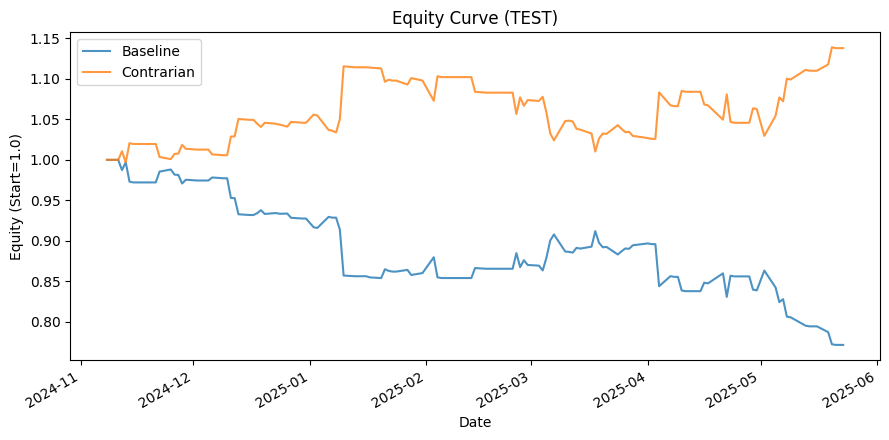

In [7]:
def backtest_from_probs(
    probs: pd.Series,
    asset_next_ret: pd.Series,
    long_th: float = 0.55,
    short_th: float = 0.45,
    cost_bps: float = 5.0,
    target_vol: float | None = None,
    vol_lookback: int = 20,
    max_leverage: float = 3.0,
):
    sig = np.where(probs > long_th, 1, np.where(probs < short_th, -1, 0)).astype(int)
    sig = pd.Series(sig, index=probs.index, name="signal")

    ret = asset_next_ret.reindex(sig.index)
    valid = ret.notna()
    sig, ret = sig[valid], ret[valid]

    if target_vol is not None:
        gross_unit = sig * ret
        rolling_vol = gross_unit.rolling(vol_lookback).std()
        daily_target = target_vol / np.sqrt(252.0)
        with np.errstate(divide="ignore", invalid="ignore"):
            lev = (daily_target / rolling_vol).clip(upper=max_leverage)
        lev = lev.fillna(0.0)
    else:
        lev = pd.Series(1.0, index=sig.index, name="leverage")

    pos = (sig * lev).rename("position")
    turnover = pos.diff().abs().fillna(pos.abs())
    cost_rate = cost_bps / 1e4
    costs = turnover * cost_rate

    gross = pos * ret
    net   = gross - costs
    equity = (1.0 + net).cumprod()

    ann = np.sqrt(252.0)
    dd = (equity / equity.cummax()) - 1.0
    summary = {
        "days": net.shape[0],
        "trades": int((turnover > 0).sum()),
        "turnover_sum": float(turnover.sum()),
        "total_return": float(equity.iloc[-1] - 1.0),
        "CAGR": float(equity.iloc[-1] ** (252.0 / net.shape[0]) - 1.0) if net.shape[0] else np.nan,
        "Sharpe": float(net.mean() / net.std() * ann) if net.std() > 0 else np.nan,
        "MaxDD": float(dd.min()) if len(dd) else np.nan,
        "HitRate": float((net > 0).mean()),
        "cost_bps": float(cost_bps),
        "long_th": float(long_th),
        "short_th": float(short_th),
        "target_vol": float(target_vol) if target_vol is not None else None,
    }
    out = pd.DataFrame({
        "ret": ret, "signal": sig, "leverage": lev, "position": pos,
        "gross_ret": gross, "costs": costs, "net_ret": net, "equity": equity
    })
    return summary, out

# Prepare next-day returns for the test index
mops_daily = mops_df.set_index("Date")[["ret_1d"]]
asset_ret_next = mops_daily["ret_1d"].shift(-1)

# Baseline (as-is) vs Contrarian (flip probs)
bt_params = dict(long_th=0.55, short_th=0.45, cost_bps=10.0, target_vol=None)

base_sum,  base_daily  = backtest_from_probs(p_test,           asset_ret_next, **bt_params)
contra_sum, contra_daily = backtest_from_probs(1.0 - p_test,   asset_ret_next, **bt_params)

def print_perf(title, summ):
    print(f"\n=== {title} ===")
    for k, v in summ.items():
        if isinstance(v, float):
            if k in ("CAGR","total_return","MaxDD","HitRate"):
                print(f"{k}: {v:.2%}")
            elif k == "Sharpe":
                print(f"{k}: {v:.2f}")
            else:
                print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

print_perf("Baseline (Logit) — TEST", base_sum)
print_perf("Contrarian — TEST", contra_sum)

# Quick equity plot
plt.figure()
base_daily["equity"].plot(label="Baseline", alpha=0.8)
contra_daily["equity"].plot(label="Contrarian", alpha=0.8)
plt.title("Equity Curve (TEST)")
plt.xlabel("Date"); plt.ylabel("Equity (Start=1.0)")
plt.legend(); plt.tight_layout(); plt.show()


Total runs: 1185

=== Top configs @ 0 bps ===


,long_th,short_th,cost_bps,Sharpe,CAGR,MaxDD,HitRate,total_return,trades
0,0.54,0.46,0.0,2.769878,0.882325,-0.058772,0.345865,0.396297,57
1,0.54,0.48,0.0,2.758784,0.925917,-0.072006,0.383459,0.413271,56
2,0.53,0.48,0.0,2.514420,0.832186,-0.072006,0.406015,0.376542,53
3,0.53,0.46,0.0,2.513217,0.790715,-0.053969,0.368421,0.360009,54
4,0.54,0.44,0.0,2.485819,0.677022,-0.068992,0.323308,0.313731,55
5,0.54,0.49,0.0,2.445141,0.797833,-0.077286,0.390977,0.362859,62
6,0.55,0.46,0.0,2.394544,0.670193,-0.058772,0.293233,0.310905,55
7,0.55,0.48,0.0,2.392371,0.708873,-0.066461,0.330827,0.326841,56
8,0.54,0.47,0.0,2.359833,0.735367,-0.084008,0.345865,0.337659,58
9,0.57,0.46,0.0,2.247637,0.499391,-0.049897,0.225564,0.238351,52



=== Top configs @ 5 bps ===


,long_th,short_th,cost_bps,Sharpe,CAGR,MaxDD,HitRate,total_return,trades
0,0.54,0.46,5.0,2.519920,0.775033,-0.063491,0.345865,0.353710,57
1,0.54,0.48,5.0,2.498345,0.805964,-0.078461,0.383459,0.366109,56
2,0.53,0.46,5.0,2.272101,0.688766,-0.055880,0.368421,0.318579,54
3,0.53,0.48,5.0,2.262145,0.718193,-0.078461,0.406015,0.330656,53
4,0.54,0.44,5.0,2.241356,0.590507,-0.076436,0.323308,0.277515,55
5,0.54,0.49,5.0,2.149589,0.669859,-0.086568,0.390977,0.310767,62
6,0.55,0.46,5.0,2.138079,0.577937,-0.066578,0.293233,0.272176,55
7,0.55,0.48,5.0,2.125131,0.605409,-0.072025,0.330827,0.283818,56
8,0.54,0.47,5.0,2.110466,0.633313,-0.091306,0.345865,0.295547,58
9,0.54,0.45,5.0,1.991757,0.512379,-0.076436,0.323308,0.244001,54



=== Top configs @ 10 bps ===


,long_th,short_th,cost_bps,Sharpe,CAGR,MaxDD,HitRate,total_return,trades
0,0.54,0.46,10.0,2.269920,0.673801,-0.068190,0.345865,0.312399,57
1,0.54,0.48,10.0,2.237253,0.693409,-0.084875,0.383459,0.320491,56
2,0.53,0.46,10.0,2.030191,0.592562,-0.058831,0.368421,0.278386,54
3,0.53,0.48,10.0,2.008546,0.611218,-0.084875,0.406015,0.286268,53
4,0.54,0.44,10.0,1.996328,0.508415,-0.083825,0.323308,0.242279,55
5,0.55,0.46,10.0,1.881702,0.490727,-0.075902,0.285714,0.234570,55
6,0.54,0.47,10.0,1.861232,0.537206,-0.098551,0.345865,0.254738,58
7,0.55,0.48,10.0,1.857501,0.508148,-0.078375,0.323308,0.242163,56
8,0.54,0.49,10.0,1.854113,0.550914,-0.098421,0.390977,0.260631,62
9,0.54,0.45,10.0,1.748006,0.434253,-0.083825,0.323308,0.209661,54



=== Top configs @ 25 bps ===


,long_th,short_th,cost_bps,Sharpe,CAGR,MaxDD,HitRate,total_return,trades
0,0.54,0.46,25.0,1.522342,0.403157,-0.093033,0.338346,0.195747,57
1,0.54,0.48,25.0,1.453540,0.395746,-0.103876,0.368421,0.192410,56
2,0.53,0.46,25.0,1.302570,0.335308,-0.076714,0.360902,0.164874,54
3,0.54,0.44,25.0,1.260408,0.286485,-0.105659,0.323308,0.142198,55
4,0.53,0.48,25.0,1.243371,0.328256,-0.103876,0.390977,0.161623,53
5,0.66,0.46,25.0,1.189304,0.181842,-0.055111,0.090226,0.092182,24
6,0.54,0.47,25.0,1.116946,0.281226,-0.119966,0.338346,0.139731,58
7,0.55,0.46,25.0,1.116176,0.256715,-0.103354,0.278195,0.128171,55
8,0.66,0.48,25.0,1.056903,0.175366,-0.082945,0.127820,0.089020,30
9,0.55,0.48,25.0,1.055938,0.250007,-0.108464,0.315789,0.124989,56



=== Top configs @ 50 bps ===


,long_th,short_th,cost_bps,Sharpe,CAGR,MaxDD,HitRate,total_return,trades
0,0.66,0.46,50.0,0.431047,0.054948,-0.066962,0.082707,0.028634,24
1,0.54,0.46,50.0,0.299677,0.045071,-0.137585,0.338346,0.023540,57
2,0.66,0.48,50.0,0.199031,0.019729,-0.094460,0.112782,0.010365,30
3,0.54,0.48,50.0,0.165986,0.010418,-0.162070,0.368421,0.005485,56
4,0.65,0.46,50.0,0.104903,0.004818,-0.066962,0.082707,0.002540,28
5,0.53,0.46,50.0,0.100568,-0.005200,-0.120349,0.360902,-0.002748,54
6,0.54,0.44,50.0,0.046135,-0.013783,-0.173112,0.323308,-0.007298,55
7,0.64,0.46,50.0,0.043833,-0.004380,-0.066962,0.082707,-0.002314,28
8,0.66,0.44,50.0,0.006898,-0.004988,-0.057084,0.067669,-0.002635,18
9,0.53,0.48,50.0,-0.025052,-0.038186,-0.155383,0.390977,-0.020339,53


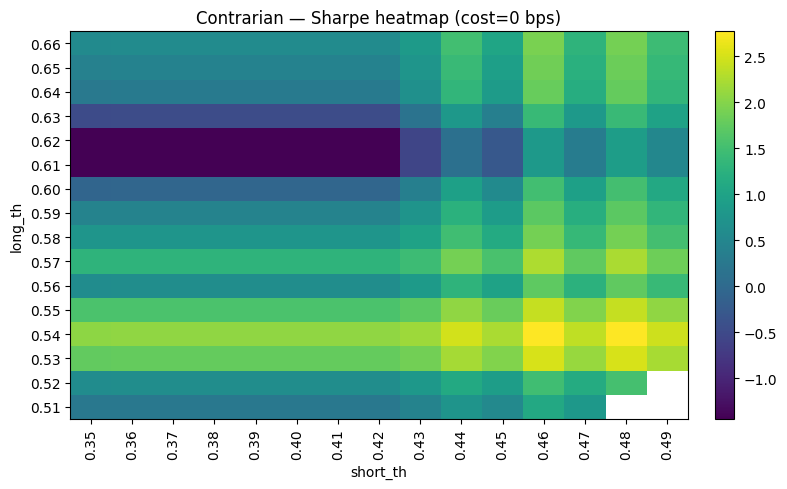

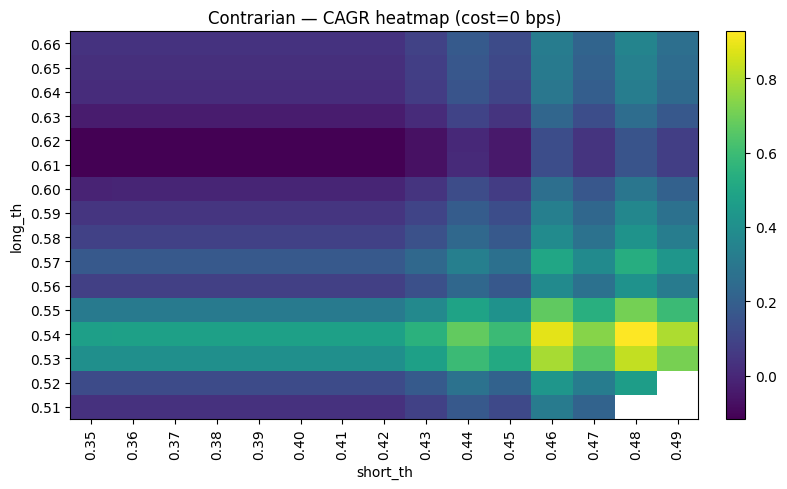

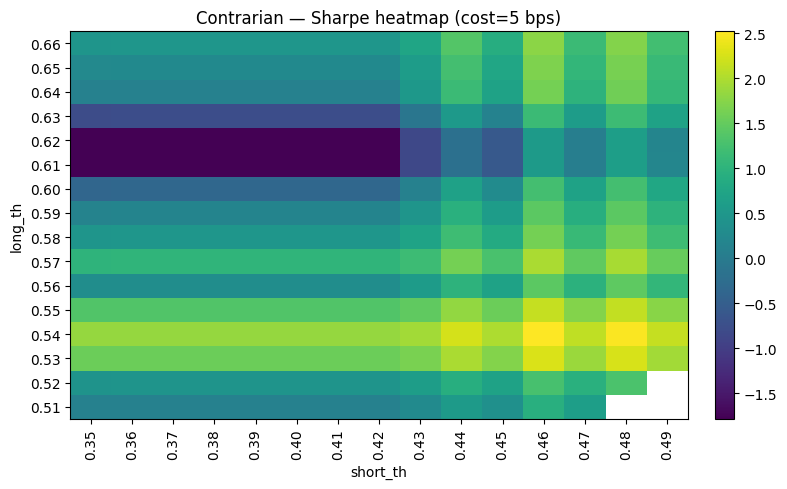

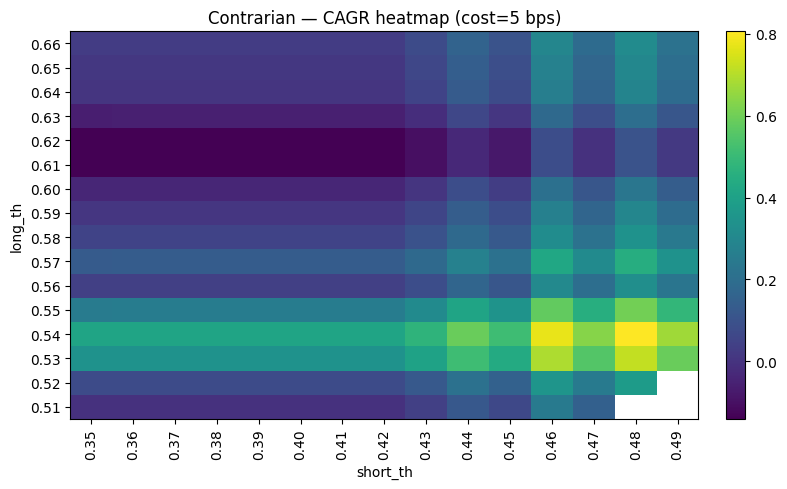

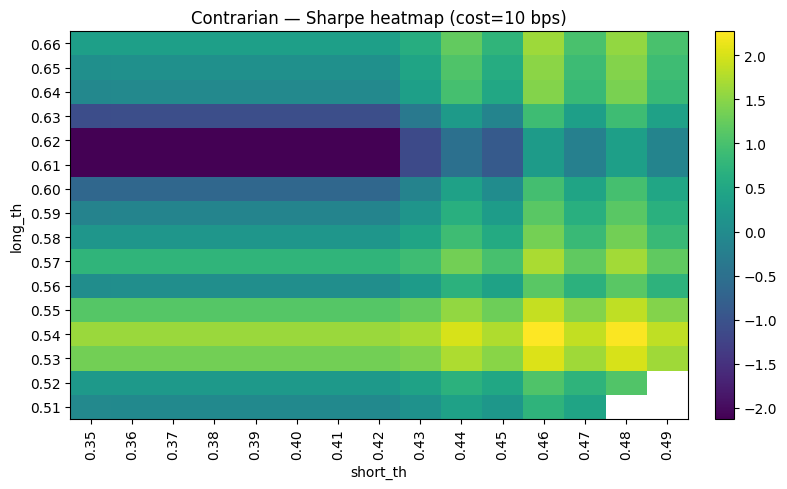

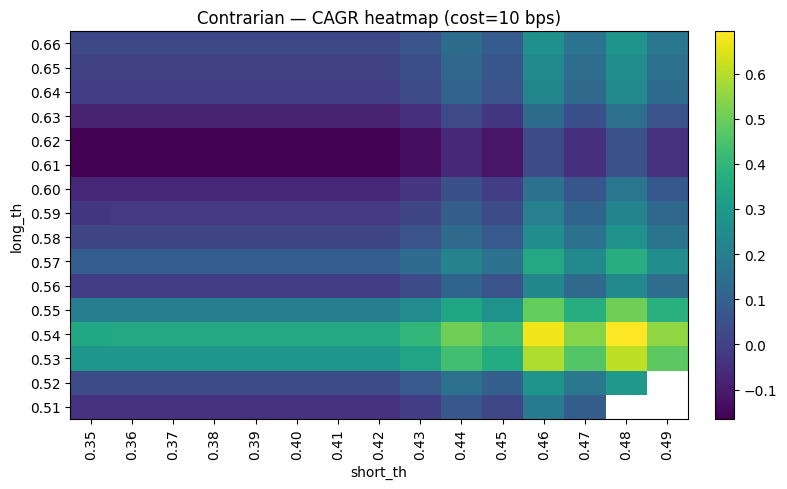

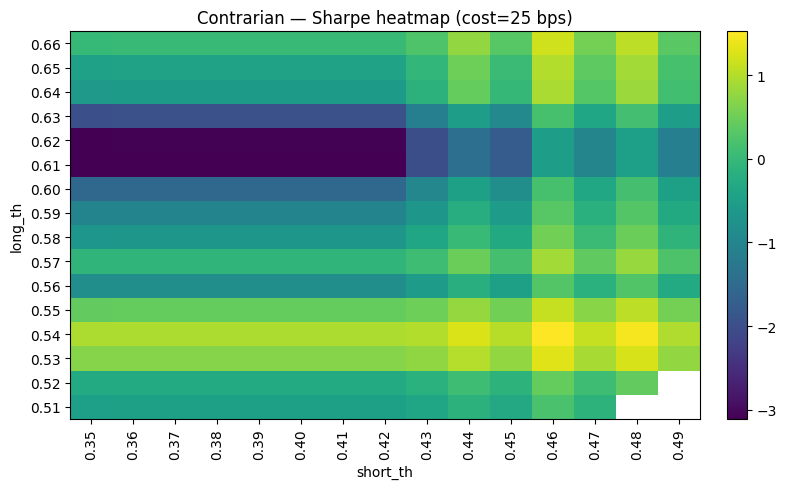

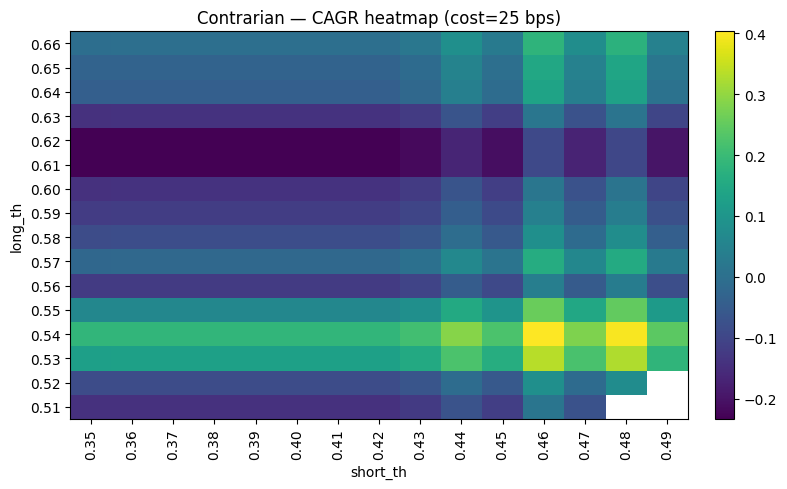

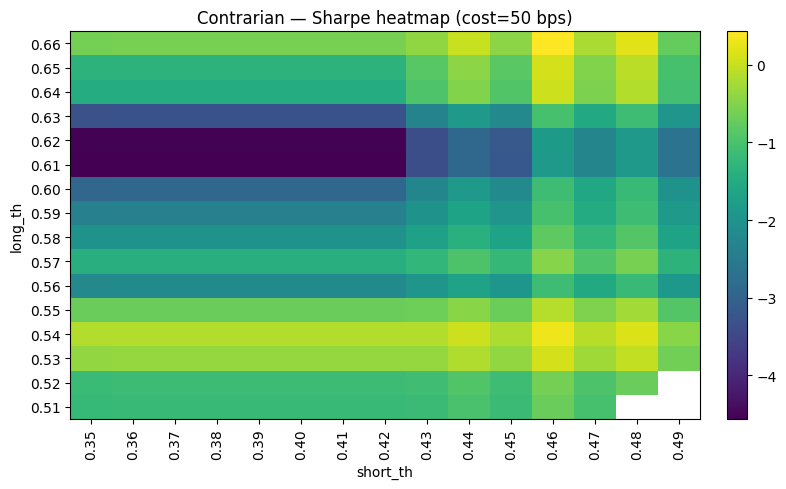

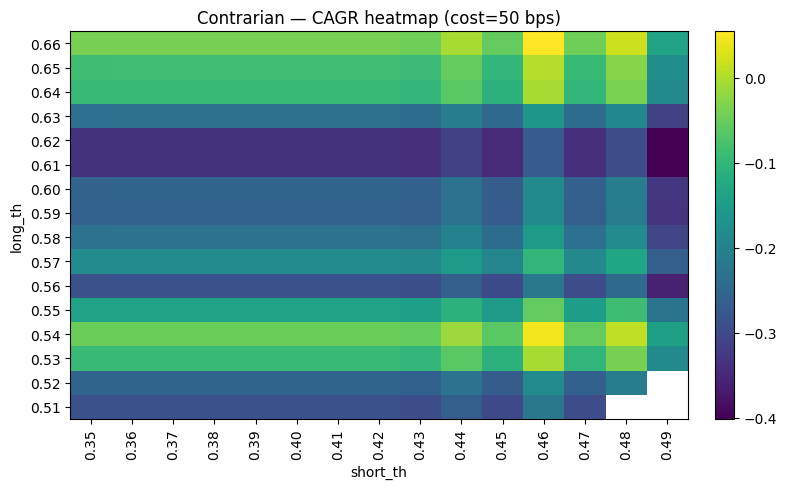

In [9]:
# --- Block 7b — Wide threshold sweep + heatmaps (Sharpe & CAGR) ---
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# Safety checks
assert 'p_test' in globals() and 'asset_ret_next' in globals(), "Run Blocks 5–6 first."
assert 'backtest_from_probs' in globals(), "Run Block 6 first."

# Grid params
long_grid  = np.round(np.arange(0.50, 0.66, 0.01), 2)   # 0.50 → 0.65
short_grid = np.round(np.arange(0.35, 0.51, 0.01), 2)   # 0.35 → 0.50
cost_list  = [0.0, 5.0, 10.0, 25.0, 50.0]

results = []
for c in cost_list:
    for lt in long_grid:
        for st in short_grid:
            # Require short_th < 0.5 < long_th and a minimum separation
            if not (st < 0.5 < lt):
                continue
            if (lt - st) < 0.04:     # avoid too-narrow bands that overtrade/noise
                continue
            # Contrarian: flip probs
            s, _ = backtest_from_probs(
                1.0 - p_test, asset_ret_next,
                long_th=lt, short_th=st, cost_bps=c, target_vol=None
            )
            results.append({
                "long_th": lt, "short_th": st, "cost_bps": c,
                "Sharpe": s["Sharpe"], "CAGR": s["CAGR"],
                "MaxDD": s["MaxDD"], "HitRate": s["HitRate"],
                "total_return": s["total_return"], "trades": s["trades"]
            })

grid_df = pd.DataFrame(results)
print("Total runs:", len(grid_df))

# Show top configs per cost by Sharpe (then CAGR)
def top_k(df, k=10):
    return (df.sort_values(["Sharpe","CAGR"], ascending=False)
              .head(k)
              .reset_index(drop=True))

for c in cost_list:
    print(f"\n=== Top configs @ {c:.0f} bps ===")
    display(top_k(grid_df[grid_df["cost_bps"]==c], k=10))

# Heatmap helper
def heatmap_metric(df, cost, metric="Sharpe", title_prefix=""):
    sub = df[df["cost_bps"]==cost].copy()
    # pivot with rows=long_th, cols=short_th
    piv = sub.pivot(index="long_th", columns="short_th", values=metric)
    # ensure full grid order
    piv = piv.reindex(index=sorted(piv.index), columns=sorted(piv.columns))
    plt.figure(figsize=(8, 5))
    im = plt.imshow(piv.values, aspect="auto", origin="lower")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(f"{title_prefix}{metric} heatmap (cost={cost:.0f} bps)")
    plt.xlabel("short_th"); plt.ylabel("long_th")
    # tick labels
    plt.xticks(ticks=np.arange(len(piv.columns)), labels=[f"{c:.2f}" for c in piv.columns], rotation=90)
    plt.yticks(ticks=np.arange(len(piv.index)),   labels=[f"{r:.2f}" for r in piv.index])
    plt.tight_layout()
    plt.show()

# Plot Sharpe & CAGR heatmaps for each cost level
for c in cost_list:
    heatmap_metric(grid_df, c, metric="Sharpe", title_prefix="Contrarian — ")
    heatmap_metric(grid_df, c, metric="CAGR",   title_prefix="Contrarian — ")


=== Contrarian @ 10 bps ===
days: 133
trades: 57
turnover_sum: 62.0000
total_return: 31.24%
CAGR: 67.38%
Sharpe: 2.27
MaxDD: -6.82%
HitRate: 34.59%
cost_bps: 10.0000
long_th: 0.5400
short_th: 0.4600
target_vol: None

=== Baseline @ 10 bps ===
days: 133
trades: 57
turnover_sum: 62.0000
total_return: -34.74%
CAGR: -55.45%
Sharpe: -3.27
MaxDD: -34.75%
HitRate: 30.83%
cost_bps: 10.0000
long_th: 0.5400
short_th: 0.4600
target_vol: None


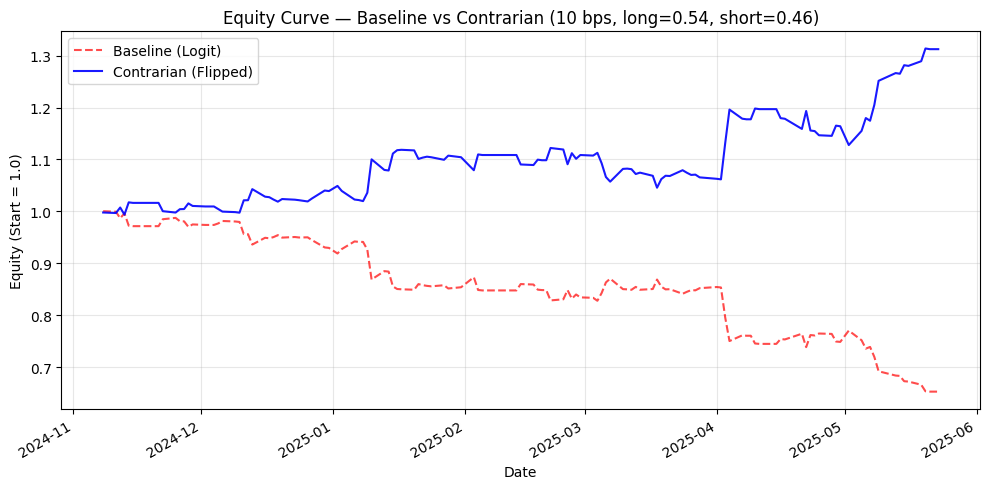

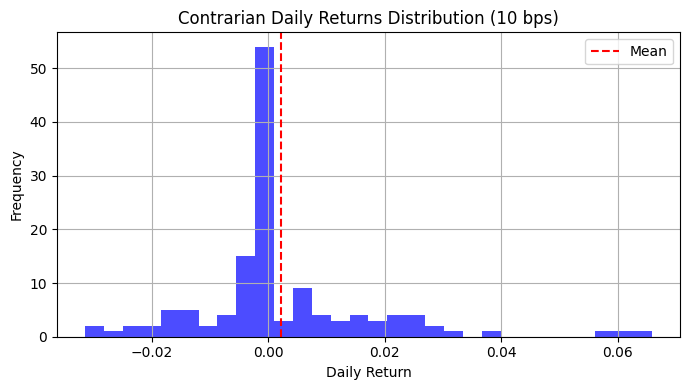

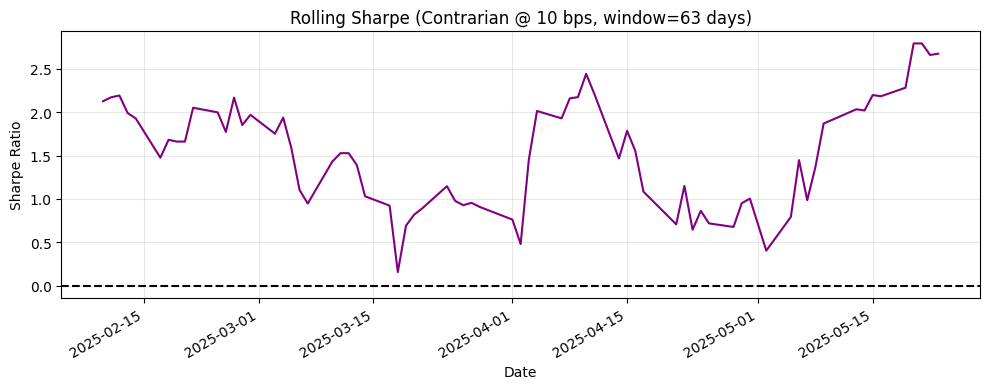

In [11]:
# --- Block 7c (10 bps version) ---

# Pick optimal config at 10 bps
best_long, best_short, best_cost = 0.54, 0.46, 10.0

# Run contrarian backtest
contra_summary, contra_daily = backtest_from_probs(
    1.0 - p_test, asset_ret_next,
    long_th=best_long, short_th=best_short, cost_bps=best_cost
)

print("=== Contrarian @ 10 bps ===")
for k, v in contra_summary.items():
    if isinstance(v, float):
        if k in ("CAGR","total_return","MaxDD","HitRate"):
            print(f"{k}: {v:.2%}")
        elif k == "Sharpe":
            print(f"{k}: {v:.2f}")
        else:
            print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# Run baseline (non-contrarian) for comparison
base_summary, base_daily = backtest_from_probs(
    p_test, asset_ret_next,
    long_th=best_long, short_th=best_short, cost_bps=best_cost
)

print("\n=== Baseline @ 10 bps ===")
for k, v in base_summary.items():
    if isinstance(v, float):
        if k in ("CAGR","total_return","MaxDD","HitRate"):
            print(f"{k}: {v:.2%}")
        elif k == "Sharpe":
            print(f"{k}: {v:.2f}")
        else:
            print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# --- Plot equity curves ---
plt.figure(figsize=(10,5))
base_daily["equity"].plot(label="Baseline (Logit)", alpha=0.7, linestyle="--", color="red")
contra_daily["equity"].plot(label="Contrarian (Flipped)", alpha=0.9, color="blue")
plt.title(f"Equity Curve — Baseline vs Contrarian (10 bps, long={best_long}, short={best_short})")
plt.xlabel("Date"); plt.ylabel("Equity (Start = 1.0)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Daily return distribution (contrarian only) ---
plt.figure(figsize=(7,4))
contra_daily["net_ret"].hist(bins=30, alpha=0.7, color="blue")
plt.axvline(contra_daily["net_ret"].mean(), color="red", linestyle="--", label="Mean")
plt.title("Contrarian Daily Returns Distribution (10 bps)")
plt.xlabel("Daily Return"); plt.ylabel("Frequency")
plt.legend(); plt.tight_layout(); plt.show()

# --- Rolling Sharpe (contrarian only) ---
rolling_window = 63  # ~1 quarter
rolling_sharpe = (contra_daily["net_ret"].rolling(rolling_window).mean() /
                  contra_daily["net_ret"].rolling(rolling_window).std()) * np.sqrt(252)

plt.figure(figsize=(10,4))
rolling_sharpe.plot(color="purple", lw=1.5)
plt.axhline(0, color="black", linestyle="--")
plt.title(f"Rolling Sharpe (Contrarian @ 10 bps, window={rolling_window} days)")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


Contrarian baseline @ 10 bps: Sharpe=2.27 | CAGR=67.38%

Top 15 features by permutation importance (ΔSharpe):


,feature,delta_sharpe_mean,delta_sharpe_std,delta_cagr_mean,delta_cagr_std
0,volume_min_sum,-3.568040,0.714613,-0.975846,0.133621
1,volume_max_sum,-3.533400,1.235548,-0.952929,0.239741
2,volume_max_mean,-3.294286,0.697439,-0.917490,0.135701
3,n_unique_parties,-3.283546,0.697664,-0.917708,0.143686
4,volume_min_count,-2.096651,0.384810,-0.656461,0.096397
5,volume_max_count,-1.882688,0.887473,-0.571568,0.255590
6,heards_price_mean,-1.828312,0.448994,-0.587984,0.114403
7,net_offer_bid,-1.689797,0.849923,-0.544467,0.206256
8,ret_1d,-1.300352,0.362145,-0.488005,0.076696
9,total_actions,-1.255724,0.134519,-0.418619,0.045936


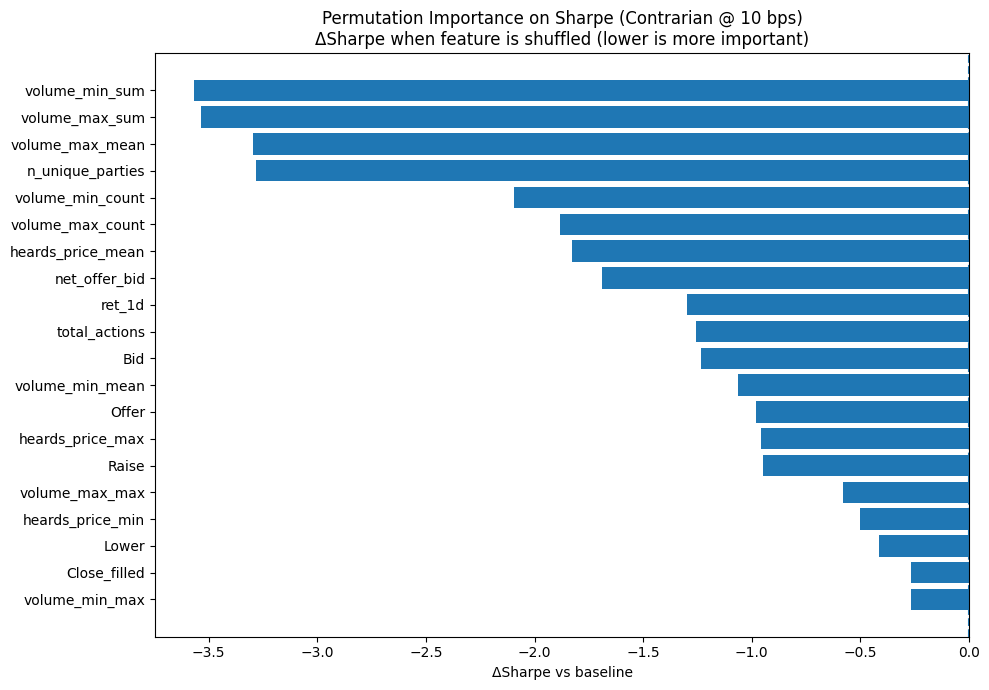


Top 20 logistic coefficients (absolute magnitude):


,feature,coef
0,volume_min_mean,0.473508
1,volume_max_sum,-0.440993
2,volume_min_sum,-0.359923
3,volume_min_count,0.315092
4,volume_max_count,0.315092
5,n_unique_parties,0.238752
6,volume_max_mean,-0.207834
7,ret_1d,-0.132435
8,Raise,0.104789
9,heards_price_mean,-0.100869


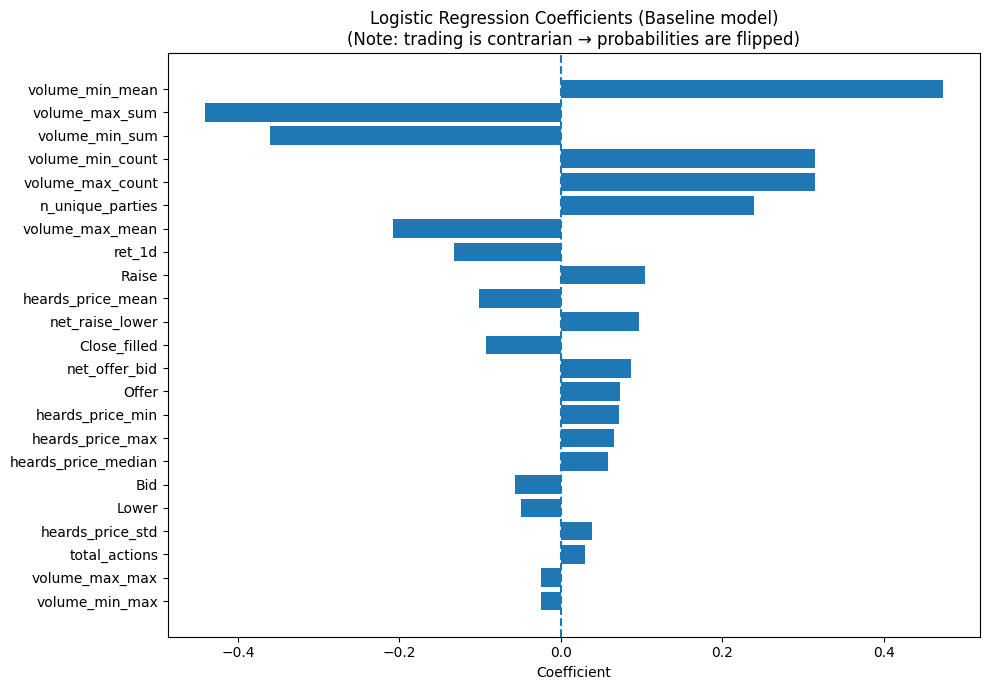


INTERPRETATION:
- Permutation plot (ΔSharpe): More negative bars = more important. If shuffling a feature kills Sharpe, it carries real signal for the CONTRARIAN strategy.
- Coefficients: Positive coef means the baseline model leans 'up' when this feature rises; since we flip, those features likely relate to next-day mean-reversion down.
- Candidates to drop: features with ΔSharpe ≈ 0 and small |coef| (weak signal).
- Next: Try pruning weakest features, retrain, and re-run Block 7b/7c to see if Sharpe/CAGR improve.



In [13]:
# --- Block 8b — Feature importance for the CONTRARIAN model (viz) ---

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy

# Safety checks
for var in ["logit_clf", "X_test", "p_test", "asset_ret_next", "backtest_from_probs"]:
    assert var in globals(), f"Missing {var}. Run previous blocks."

# Use your chosen optimal execution params (10 bps from earlier)
best_long, best_short, best_cost = 0.54, 0.46, 10.0

# Baseline CONTRARIAN performance on test
base_sum, base_daily = backtest_from_probs(
    1.0 - p_test, asset_ret_next,
    long_th=best_long, short_th=best_short, cost_bps=best_cost
)
base_sharpe = base_sum["Sharpe"]
base_cagr   = base_sum["CAGR"]

print(f"Contrarian baseline @ 10 bps: Sharpe={base_sharpe:.2f} | CAGR={base_cagr:.2%}")

# ---------- 1) Permutation importance on Sharpe ----------
rng = np.random.default_rng(42)
feature_names = X_test.columns
perm_rows = []

# We'll run a single shuffle per feature for speed; increase n_repeats for more stability
n_repeats = 5

for feat in feature_names:
    deltas_sharpe = []
    deltas_cagr   = []
    for _ in range(n_repeats):
        Xp = X_test.copy()
        Xp[feat] = rng.permutation(Xp[feat].values)  # shuffle this feature over the test dates

        # Recompute probs with trained pipeline
        p_perm = pd.Series(logit_clf.predict_proba(Xp)[:, 1], index=Xp.index, name="p_up")

        # CONTRARIAN backtest
        s_perm, _ = backtest_from_probs(
            1.0 - p_perm, asset_ret_next,
            long_th=best_long, short_th=best_short, cost_bps=best_cost
        )
        deltas_sharpe.append(s_perm["Sharpe"] - base_sharpe)
        deltas_cagr.append(s_perm["CAGR"] - base_cagr)

    perm_rows.append({
        "feature": feat,
        "delta_sharpe_mean": float(np.mean(deltas_sharpe)),
        "delta_sharpe_std": float(np.std(deltas_sharpe)),
        "delta_cagr_mean": float(np.mean(deltas_cagr)),
        "delta_cagr_std": float(np.std(deltas_cagr)),
    })

perm_df = pd.DataFrame(perm_rows)
# Sort by most negative ΔSharpe (biggest harm when shuffled)
perm_df = perm_df.sort_values("delta_sharpe_mean").reset_index(drop=True)

print("\nTop 15 features by permutation importance (ΔSharpe):")
display(perm_df.head(15))

# Plot ΔSharpe (most important first)
topN = 20
plt.figure(figsize=(10, 7))
subset = perm_df.head(topN).iloc[::-1]  # plot topN with most important at top
plt.barh(subset["feature"], subset["delta_sharpe_mean"])
plt.axvline(0, linestyle="--")
plt.title(f"Permutation Importance on Sharpe (Contrarian @ {best_cost:.0f} bps)\nΔSharpe when feature is shuffled (lower is more important)")
plt.xlabel("ΔSharpe vs baseline")
plt.tight_layout()
plt.show()

# ---------- 2) Logistic coefficients (for sign intuition) ----------
coefs = logit_clf.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
# Sort by absolute magnitude
coef_df = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index).reset_index(drop=True)

print("\nTop 20 logistic coefficients (absolute magnitude):")
display(coef_df.head(20))

plt.figure(figsize=(10, 7))
plot_df = coef_df.head(25).iloc[::-1]  # top 25, inverted for barh order
plt.barh(plot_df["feature"], plot_df["coef"])
plt.axvline(0, linestyle="--")
plt.title("Logistic Regression Coefficients (Baseline model)\n(Note: trading is contrarian → probabilities are flipped)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

# ---------- Helper: quick guidance printed ----------
print("""
INTERPRETATION:
- Permutation plot (ΔSharpe): More negative bars = more important. If shuffling a feature kills Sharpe, it carries real signal for the CONTRARIAN strategy.
- Coefficients: Positive coef means the baseline model leans 'up' when this feature rises; since we flip, those features likely relate to next-day mean-reversion down.
- Candidates to drop: features with ΔSharpe ≈ 0 and small |coef| (weak signal).
- Next: Try pruning weakest features, retrain, and re-run Block 7b/7c to see if Sharpe/CAGR improve.
""")


In [14]:
# --- Block 9a: Select top features by permutation ΔSharpe and prune the dataset ---

assert 'perm_df' in globals(), "Run Block 8b first to compute perm_df."
assert set(['X_train','X_val','X_test','y_train','y_val','y_test']).issubset(globals()), "Run Blocks 5–6."

TOP_K = 12  # tune: 8–15 is reasonable based on your table

# Sort: most negative delta_sharpe_mean (bigger harm when shuffled) → most important
keep_feats = perm_df.sort_values('delta_sharpe_mean').head(TOP_K)['feature'].tolist()
print(f"Keeping {len(keep_feats)} features:", keep_feats)

# Optionally make sure we don't keep CLi-derived leakage features (keep them only if you intend to)
EXCLUDE = []  # e.g., EXCLUDE = ["Close_filled","ret_1d"]
keep_feats = [f for f in keep_feats if f not in EXCLUDE]

# Build pruned matrices (align columns)
X_train_pruned = X_train[keep_feats].copy()
X_val_pruned   = X_val[keep_feats].copy()
X_test_pruned  = X_test[keep_feats].copy()

X_train_pruned.shape, X_val_pruned.shape, X_test_pruned.shape


Keeping 12 features: ['volume_min_sum', 'volume_max_sum', 'volume_max_mean', 'n_unique_parties', 'volume_min_count', 'volume_max_count', 'heards_price_mean', 'net_offer_bid', 'ret_1d', 'total_actions', 'Bid', 'volume_min_mean']


((1060, 12), (132, 12), (133, 12))

Train (Model2) — Acc: 0.548 | ROC-AUC: 0.569
Val   (Model2) — Acc: 0.508 | ROC-AUC: 0.527
Test  (Model2) — Acc: 0.496 | ROC-AUC: 0.506

=== Model 1 (All features) — Contrarian @10 bps ===
days: 133
trades: 57
turnover_sum: 62.0000
total_return: 31.24%
CAGR: 67.38%
Sharpe: 2.27
MaxDD: -6.82%
HitRate: 34.59%
cost_bps: 10.0000
long_th: 0.5400
short_th: 0.4600
target_vol: None

=== Model 2 (Pruned)      — Contrarian @10 bps ===
days: 133
trades: 65
turnover_sum: 72.0000
total_return: 11.89%
CAGR: 23.72%
Sharpe: 1.09
MaxDD: -9.36%
HitRate: 20.30%
cost_bps: 10.0000
long_th: 0.5400
short_th: 0.4600
target_vol: None


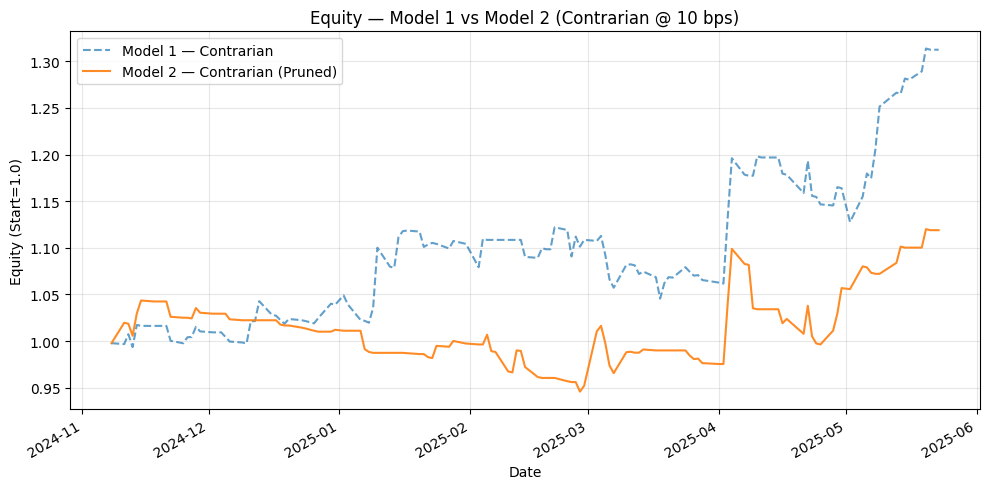

In [15]:
# --- Block 9b: Retrain logistic regression on pruned features and evaluate ---

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

logit_pruned = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1)),
])

logit_pruned.fit(X_train_pruned, y_train)

def eval_split_probs(model, Xs, ys, name=""):
    p = model.predict_proba(Xs)[:,1]
    acc = accuracy_score(ys, p >= 0.5)
    try:
        auc = roc_auc_score(ys, p)
    except ValueError:
        auc = float('nan')
    print(f"{name} — Acc: {acc:.3f} | ROC-AUC: {auc:.3f}")
    return pd.Series(p, index=ys.index, name="p_up")

p_train2 = eval_split_probs(logit_pruned, X_train_pruned, y_train, "Train (Model2)")
p_val2   = eval_split_probs(logit_pruned, X_val_pruned,   y_val,   "Val   (Model2)")
p_test2  = eval_split_probs(logit_pruned, X_test_pruned,  y_test,  "Test  (Model2)")

# Backtest (Contrarian) @ 10 bps using same optimal thresholds (adjust if you picked others)
best_long, best_short, best_cost = 0.54, 0.46, 10.0

sum2, daily2 = backtest_from_probs(1.0 - p_test2, asset_ret_next,
                                   long_th=best_long, short_th=best_short, cost_bps=best_cost)

# For side-by-side: reuse Model 1 if not already in memory
sum1, daily1 = backtest_from_probs(1.0 - p_test, asset_ret_next,
                                   long_th=best_long, short_th=best_short, cost_bps=best_cost)

def show_perf(label, s):
    print(f"\n=== {label} ===")
    for k, v in s.items():
        if isinstance(v, float):
            if k in ("CAGR","total_return","MaxDD","HitRate"):
                print(f"{k}: {v:.2%}")
            elif k == "Sharpe":
                print(f"{k}: {v:.2f}")
            else:
                print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

show_perf("Model 1 (All features) — Contrarian @10 bps", sum1)
show_perf("Model 2 (Pruned)      — Contrarian @10 bps", sum2)

# Plot equity comparison
plt.figure(figsize=(10,5))
daily1["equity"].plot(label="Model 1 — Contrarian", alpha=0.7, linestyle="--")
daily2["equity"].plot(label="Model 2 — Contrarian (Pruned)", alpha=0.9)
plt.title(f"Equity — Model 1 vs Model 2 (Contrarian @ {best_cost:.0f} bps)")
plt.xlabel("Date"); plt.ylabel("Equity (Start=1.0)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


Model 2 runs: 948

=== Model 2 — Top configs @ 0 bps ===


,long_th,short_th,cost_bps,Sharpe,CAGR,MaxDD,HitRate,total_return,trades
0,0.52,0.47,0.0,2.506831,0.797091,-0.060043,0.368421,0.362562,65
1,0.53,0.47,0.0,2.479696,0.743486,-0.060043,0.330827,0.340958,72
2,0.51,0.47,0.0,2.419130,0.778844,-0.060043,0.383459,0.355243,64
3,0.52,0.43,0.0,2.393840,0.629852,-0.049982,0.240602,0.294098,52
4,0.53,0.43,0.0,2.377127,0.581236,-0.059789,0.203008,0.273579,56
5,0.62,0.47,0.0,2.310585,0.576280,-0.076597,0.203008,0.271471,43
6,0.51,0.43,0.0,2.287961,0.613304,-0.050682,0.255639,0.287146,52
7,0.59,0.47,0.0,2.268965,0.582579,-0.071313,0.218045,0.274150,46
8,0.63,0.47,0.0,2.250603,0.556668,-0.076597,0.195489,0.263097,42
9,0.64,0.47,0.0,2.250603,0.556668,-0.076597,0.195489,0.263097,42



=== Model 2 — Top configs @ 5 bps ===


,long_th,short_th,cost_bps,Sharpe,CAGR,MaxDD,HitRate,total_return,trades
0,0.52,0.47,5.0,2.196254,0.664665,-0.065177,0.360902,0.308614,65
1,0.52,0.43,5.0,2.156033,0.547432,-0.053293,0.225564,0.259136,52
2,0.62,0.43,5.0,2.147357,0.405663,-0.050865,0.067669,0.196874,17
3,0.53,0.47,5.0,2.140871,0.608973,-0.065177,0.323308,0.285322,72
4,0.51,0.47,5.0,2.114973,0.647761,-0.065177,0.383459,0.301583,64
5,0.62,0.47,5.0,2.114049,0.512187,-0.079843,0.203008,0.243918,43
6,0.53,0.43,5.0,2.108066,0.495650,-0.064005,0.187970,0.236720,56
7,0.63,0.43,5.0,2.079649,0.390721,-0.050865,0.060150,0.190142,16
8,0.64,0.43,5.0,2.079649,0.390721,-0.050865,0.060150,0.190142,16
9,0.59,0.43,5.0,2.062411,0.405967,-0.050865,0.075188,0.197011,20



=== Model 2 — Top configs @ 10 bps ===


,long_th,short_th,cost_bps,Sharpe,CAGR,MaxDD,HitRate,total_return,trades
0,0.62,0.43,10.0,2.055563,0.382123,-0.052288,0.067669,0.186253,17
1,0.63,0.43,10.0,1.994635,0.369943,-0.052288,0.060150,0.180724,16
2,0.64,0.43,10.0,1.994635,0.369943,-0.052288,0.060150,0.180724,16
3,0.59,0.43,10.0,1.952338,0.377214,-0.052288,0.075188,0.184028,20
4,0.52,0.43,10.0,1.916088,0.469139,-0.056594,0.218045,0.225101,52
5,0.62,0.47,10.0,1.915770,0.450669,-0.083079,0.203008,0.216949,43
6,0.65,0.43,10.0,1.897845,0.347317,-0.052288,0.052632,0.170392,14
7,0.66,0.43,10.0,1.897845,0.347317,-0.052288,0.052632,0.170392,14
8,0.52,0.47,10.0,1.884312,0.541916,-0.070286,0.353383,0.256765,65
9,0.63,0.47,10.0,1.868482,0.437885,-0.083079,0.195489,0.211276,42



=== Model 2 — Top configs @ 25 bps ===


,long_th,short_th,cost_bps,Sharpe,CAGR,MaxDD,HitRate,total_return,trades
0,0.62,0.43,25.0,1.770689,0.313772,-0.05655,0.067669,0.154921,17
1,0.63,0.43,25.0,1.733527,0.309394,-0.05655,0.060150,0.152888,16
2,0.64,0.43,25.0,1.733527,0.309394,-0.05655,0.060150,0.152888,16
3,0.65,0.43,25.0,1.669427,0.295082,-0.05655,0.052632,0.146220,14
4,0.66,0.43,25.0,1.669427,0.295082,-0.05655,0.052632,0.146220,14
5,0.59,0.43,25.0,1.611240,0.294342,-0.05655,0.075188,0.145874,20
6,0.62,0.44,25.0,1.344974,0.233234,-0.05655,0.075188,0.116997,23
7,0.60,0.43,25.0,1.339897,0.230514,-0.05655,0.067669,0.115696,19
8,0.61,0.43,25.0,1.339897,0.230514,-0.05655,0.067669,0.115696,19
9,0.63,0.44,25.0,1.313466,0.229125,-0.05655,0.067669,0.115031,22


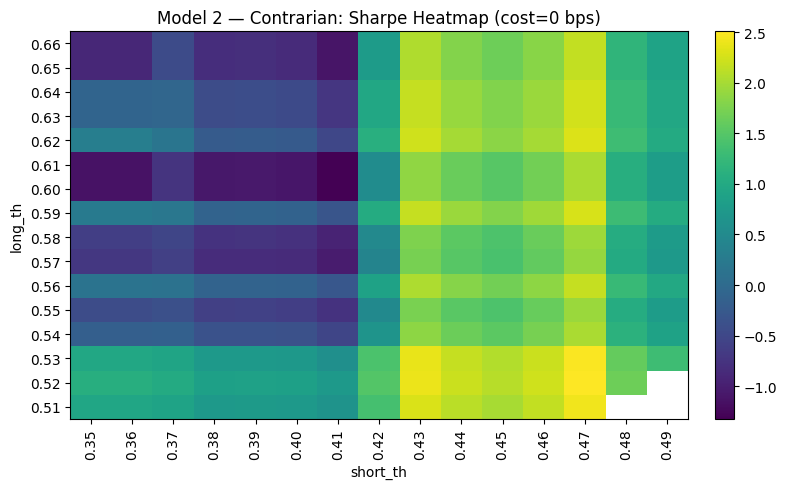

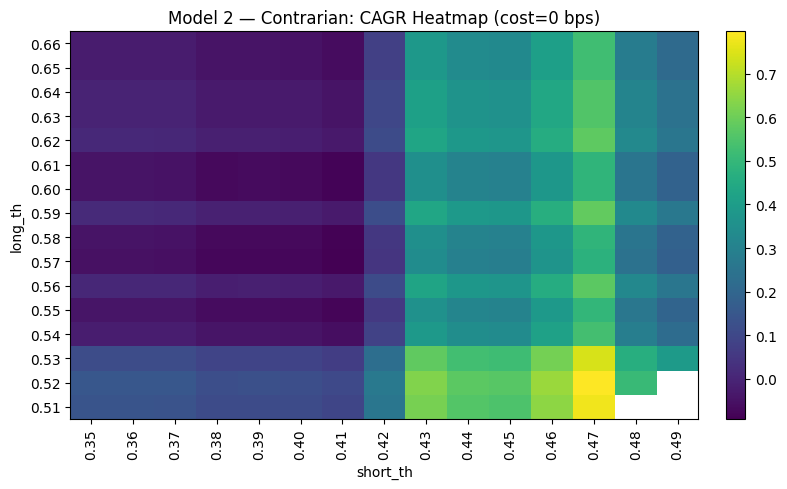

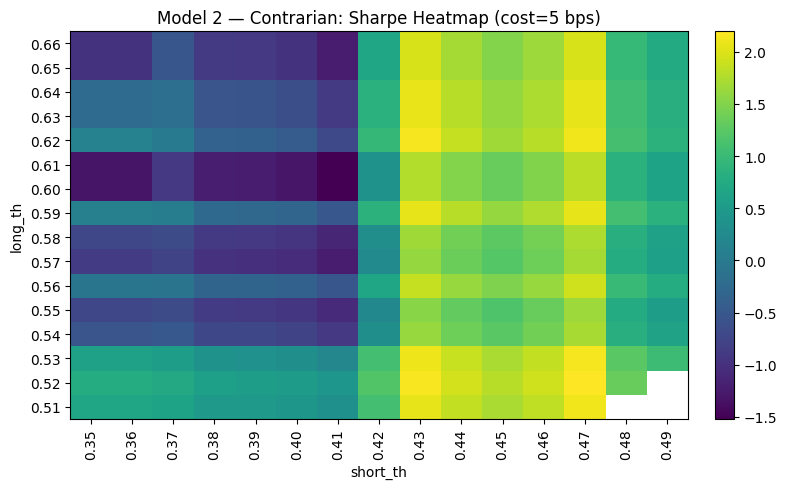

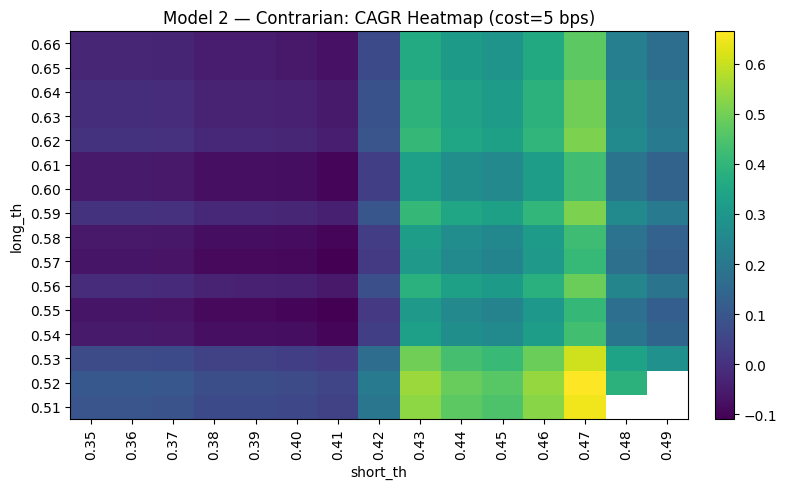

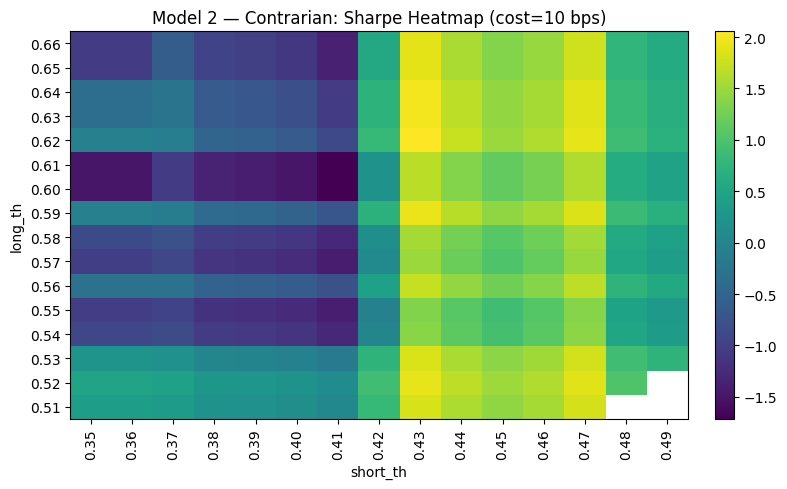

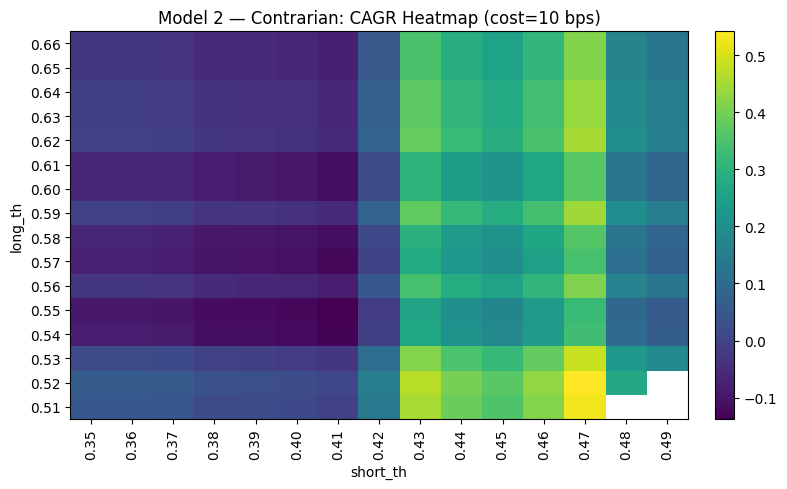

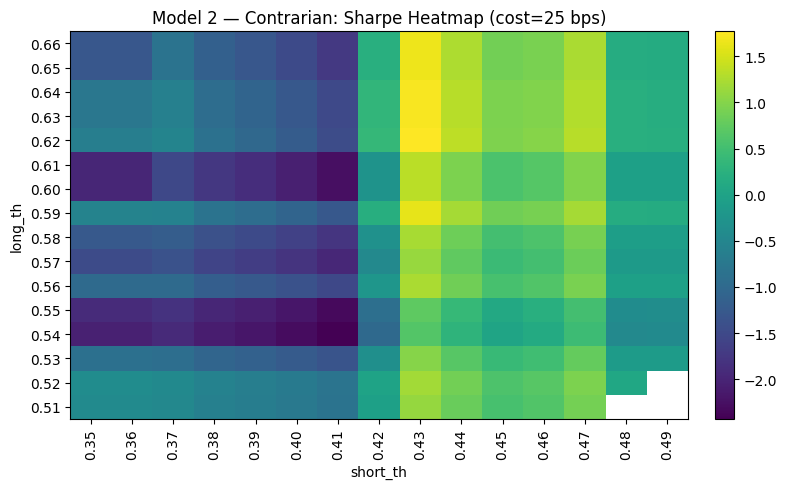

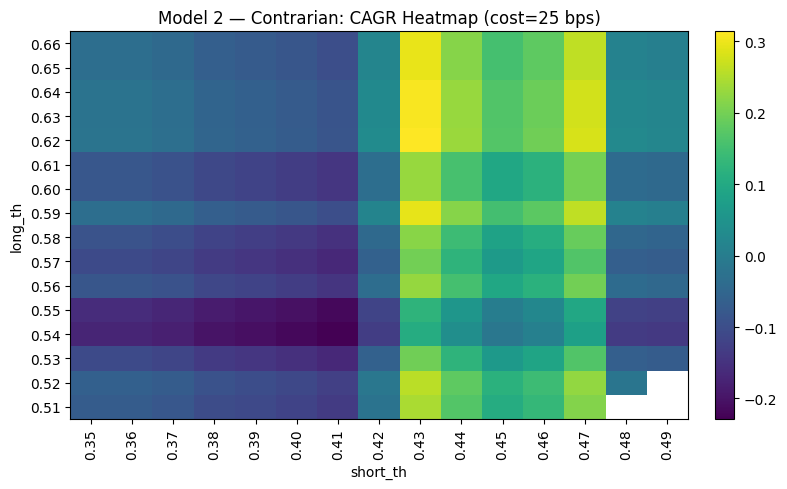

In [16]:
# --- Block 9c: Wide threshold sweep for Model 2 + heatmaps ---

assert 'backtest_from_probs' in globals(), "Run Block 6 first."

long_grid  = np.round(np.arange(0.50, 0.66, 0.01), 2)
short_grid = np.round(np.arange(0.35, 0.51, 0.01), 2)
cost_list  = [0.0, 5.0, 10.0, 25.0]

# Recompute test probs with pruned model (already computed as p_test2)
results2 = []
for c in cost_list:
    for lt in long_grid:
        for st in short_grid:
            if not (st < 0.5 < lt):
                continue
            if (lt - st) < 0.04:
                continue
            s, _ = backtest_from_probs(1.0 - p_test2, asset_ret_next,
                                       long_th=lt, short_th=st, cost_bps=c)
            results2.append({
                "long_th": lt, "short_th": st, "cost_bps": c,
                "Sharpe": s["Sharpe"], "CAGR": s["CAGR"],
                "MaxDD": s["MaxDD"], "HitRate": s["HitRate"],
                "total_return": s["total_return"], "trades": s["trades"]
            })
grid2 = pd.DataFrame(results2)
print("Model 2 runs:", len(grid2))

def top_k(df, k=10):
    return df.sort_values(["Sharpe","CAGR"], ascending=False).head(k).reset_index(drop=True)

for c in cost_list:
    print(f"\n=== Model 2 — Top configs @ {c:.0f} bps ===")
    display(top_k(grid2[grid2["cost_bps"]==c], 10))

# Heatmaps
def heatmap(df, cost, metric="Sharpe", title_prefix="Model 2 — Contrarian: "):
    sub = df[df["cost_bps"]==cost].copy()
    piv = sub.pivot(index="long_th", columns="short_th", values=metric)
    piv = piv.reindex(index=sorted(piv.index), columns=sorted(piv.columns))
    plt.figure(figsize=(8,5))
    im = plt.imshow(piv.values, aspect="auto", origin="lower")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(f"{title_prefix}{metric} Heatmap (cost={cost:.0f} bps)")
    plt.xlabel("short_th"); plt.ylabel("long_th")
    plt.xticks(range(len(piv.columns)), [f"{c:.2f}" for c in piv.columns], rotation=90)
    plt.yticks(range(len(piv.index)),   [f"{r:.2f}" for r in piv.index])
    plt.tight_layout(); plt.show()

for c in cost_list:
    heatmap(grid2, c, metric="Sharpe")
    heatmap(grid2, c, metric="CAGR")



=== Model 2B (L1 Logistic, contrarian @10 bps) ===
days: 133
trades: 49
turnover_sum: 52.0000
total_return: -7.15%
CAGR: -13.12%
Sharpe: -0.70
MaxDD: -13.29%
HitRate: 11.28%
cost_bps: 10.0000
long_th: 0.5400
short_th: 0.4600
target_vol: None


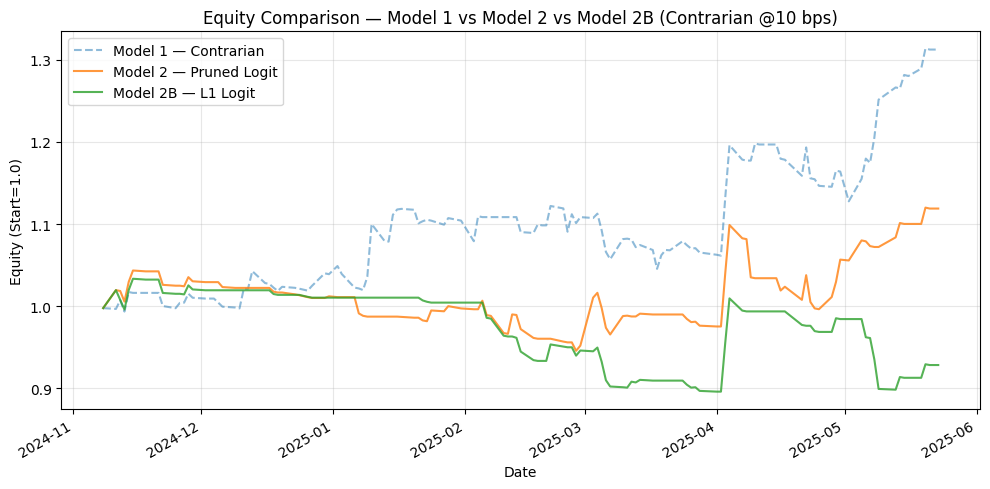

In [17]:
# --- Block 9d: L1 Logistic as an alternative "Model 2B" (learns sparsity) ---

from sklearn.linear_model import LogisticRegression

logit_L1 = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(
        penalty="l1", solver="saga", max_iter=5000, class_weight="balanced", C=0.5, n_jobs=-1
    )),
])

logit_L1.fit(X_train[keep_feats], y_train)

p_test_L1 = pd.Series(logit_L1.predict_proba(X_test[keep_feats])[:,1], index=X_test.index, name="p_up")
sum_L1, daily_L1 = backtest_from_probs(1.0 - p_test_L1, asset_ret_next,
                                       long_th=best_long, short_th=best_short, cost_bps=best_cost)

show_perf("Model 2B (L1 Logistic, contrarian @10 bps)", sum_L1)

# Compare three equity curves
plt.figure(figsize=(10,5))
daily1["equity"].plot(label="Model 1 — Contrarian", alpha=0.5, linestyle="--")
daily2["equity"].plot(label="Model 2 — Pruned Logit", alpha=0.8)
daily_L1["equity"].plot(label="Model 2B — L1 Logit", alpha=0.8)
plt.title("Equity Comparison — Model 1 vs Model 2 vs Model 2B (Contrarian @10 bps)")
plt.xlabel("Date"); plt.ylabel("Equity (Start=1.0)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


Train (RF) — Acc: 0.844 | ROC-AUC: 0.915
Val   (RF) — Acc: 0.523 | ROC-AUC: 0.537
Test  (RF) — Acc: 0.579 | ROC-AUC: 0.541

=== RF — Baseline @10 bps ===
days: 133
trades: 59
turnover_sum: 63.0000
total_return: -30.92%
CAGR: -50.38%
Sharpe: -3.07
MaxDD: -31.32%
HitRate: 22.56%
cost_bps: 10.0000
long_th: 0.5400
short_th: 0.4600
target_vol: None

=== RF — Contrarian @10 bps ===
days: 133
trades: 59
turnover_sum: 63.0000
total_return: 24.33%
CAGR: 51.09%
Sharpe: 1.99
MaxDD: -8.71%
HitRate: 22.56%
cost_bps: 10.0000
long_th: 0.5400
short_th: 0.4600
target_vol: None

=== Logit (Model 1) — Contrarian @10 bps ===
days: 133
trades: 57
turnover_sum: 62.0000
total_return: 31.24%
CAGR: 67.38%
Sharpe: 2.27
MaxDD: -6.82%
HitRate: 34.59%
cost_bps: 10.0000
long_th: 0.5400
short_th: 0.4600
target_vol: None


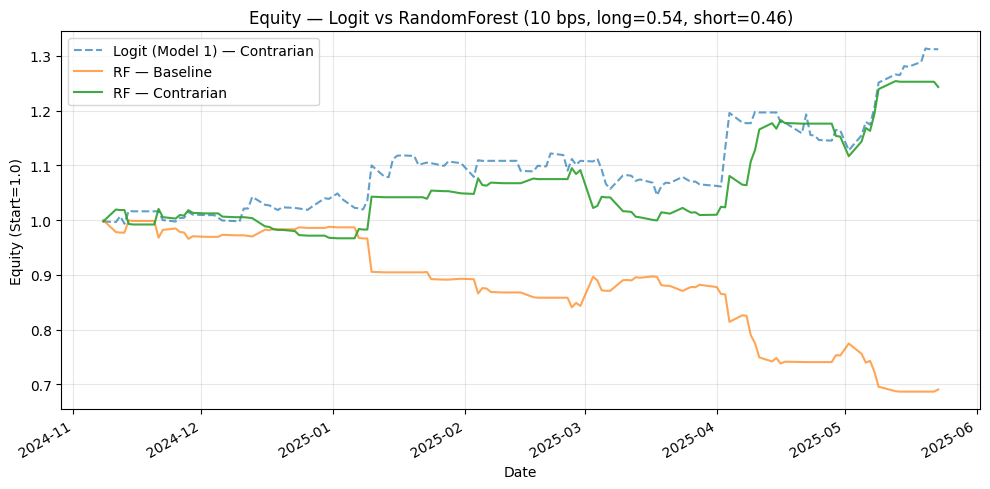

In [18]:
# --- Block 10a: RandomForestClassifier (baseline vs contrarian) ---

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train RF on ALL features (since pruning hurt)
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    oob_score=True
)
rf.fit(X_train, y_train)

def eval_split_probs_model(model, Xs, ys, name=""):
    p = model.predict_proba(Xs)[:,1]
    acc = accuracy_score(ys, (p >= 0.5).astype(int))
    try:
        auc = roc_auc_score(ys, p)
    except ValueError:
        auc = float('nan')
    print(f"{name} — Acc: {acc:.3f} | ROC-AUC: {auc:.3f}")
    return pd.Series(p, index=ys.index, name="p_up")

p_train_rf = eval_split_probs_model(rf, X_train, y_train, "Train (RF)")
p_val_rf   = eval_split_probs_model(rf, X_val,   y_val,   "Val   (RF)")
p_test_rf  = eval_split_probs_model(rf, X_test,  y_test,  "Test  (RF)")

# Backtest @ 10 bps with same thresholds you used for Logit
best_long, best_short, best_cost = 0.54, 0.46, 10.0

# Baseline RF
rf_base_sum, rf_base_daily = backtest_from_probs(p_test_rf, asset_ret_next,
                                                 long_th=best_long, short_th=best_short, cost_bps=best_cost)
# Contrarian RF
rf_contra_sum, rf_contra_daily = backtest_from_probs(1.0 - p_test_rf, asset_ret_next,
                                                     long_th=best_long, short_th=best_short, cost_bps=best_cost)

# Logit (Model 1) for comparison, if not in memory recompute quickly
logit_sum, logit_daily = backtest_from_probs(1.0 - p_test, asset_ret_next,
                                             long_th=best_long, short_th=best_short, cost_bps=best_cost)

def show_perf(label, s):
    print(f"\n=== {label} ===")
    for k, v in s.items():
        if isinstance(v, float):
            if k in ("CAGR","total_return","MaxDD","HitRate"):
                print(f"{k}: {v:.2%}")
            elif k == "Sharpe":
                print(f"{k}: {v:.2f}")
            else:
                print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")

show_perf("RF — Baseline @10 bps", rf_base_sum)
show_perf("RF — Contrarian @10 bps", rf_contra_sum)
show_perf("Logit (Model 1) — Contrarian @10 bps", logit_sum)

# Equity comparison
plt.figure(figsize=(10,5))
logit_daily["equity"].plot(label="Logit (Model 1) — Contrarian", linestyle="--", alpha=0.7)
rf_base_daily["equity"].plot(label="RF — Baseline", alpha=0.7)
rf_contra_daily["equity"].plot(label="RF — Contrarian", alpha=0.9)
plt.title(f"Equity — Logit vs RandomForest (10 bps, long={best_long}, short={best_short})")
plt.xlabel("Date"); plt.ylabel("Equity (Start=1.0)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


RF runs: 1422


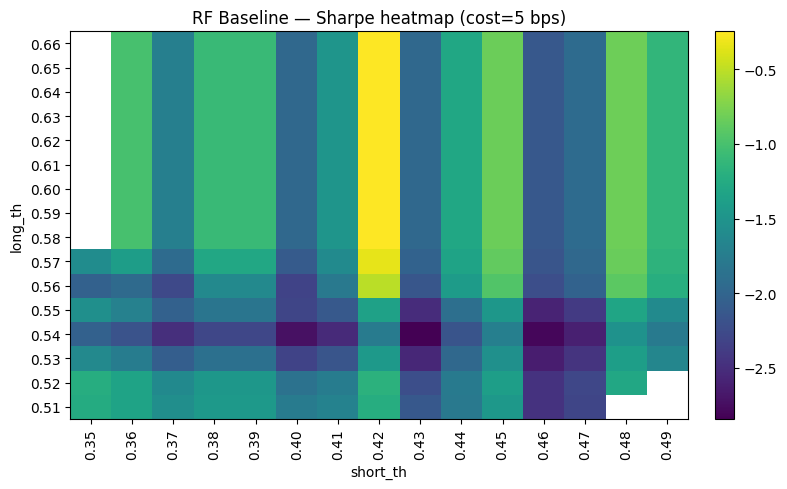

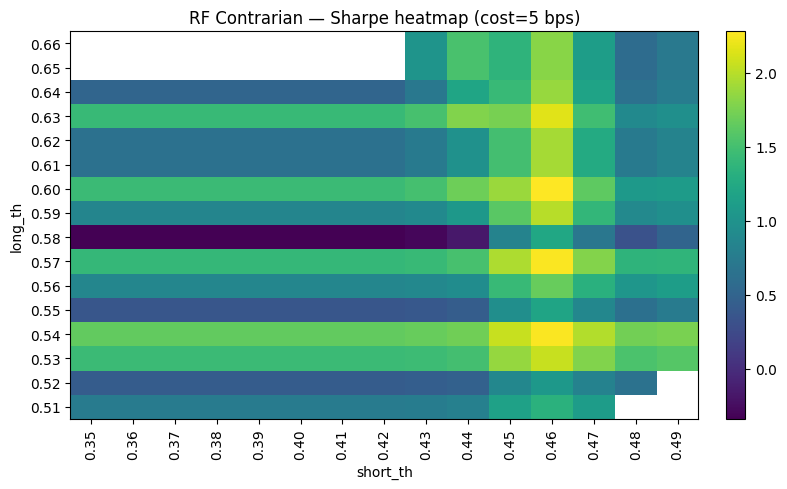

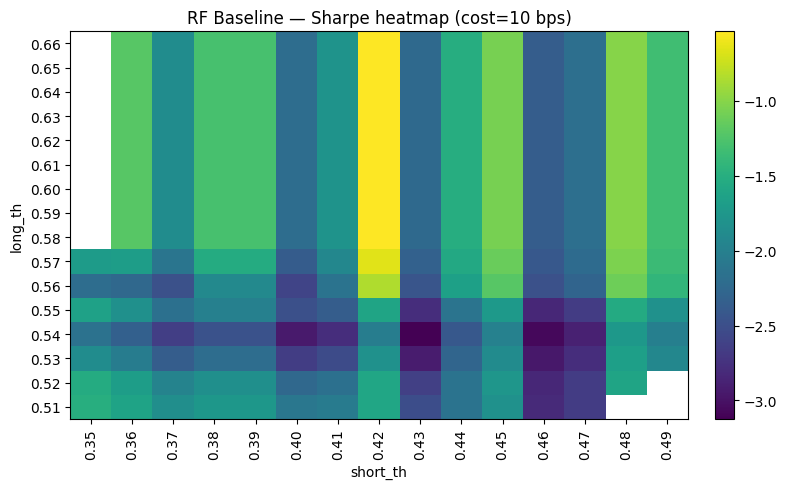

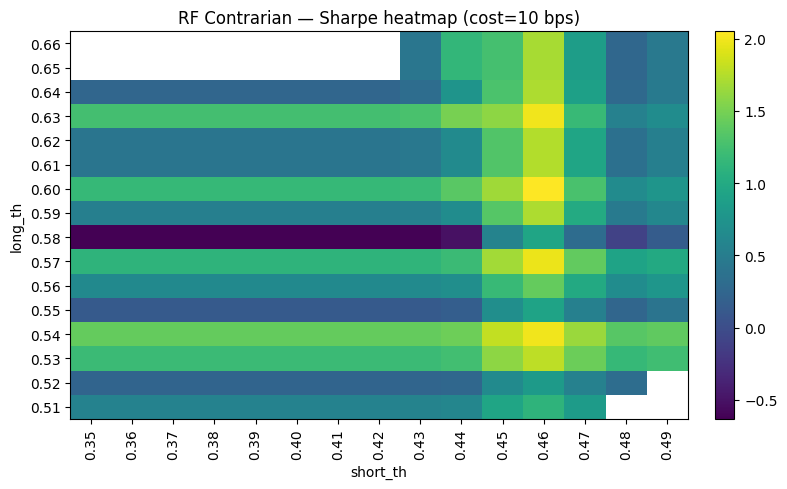

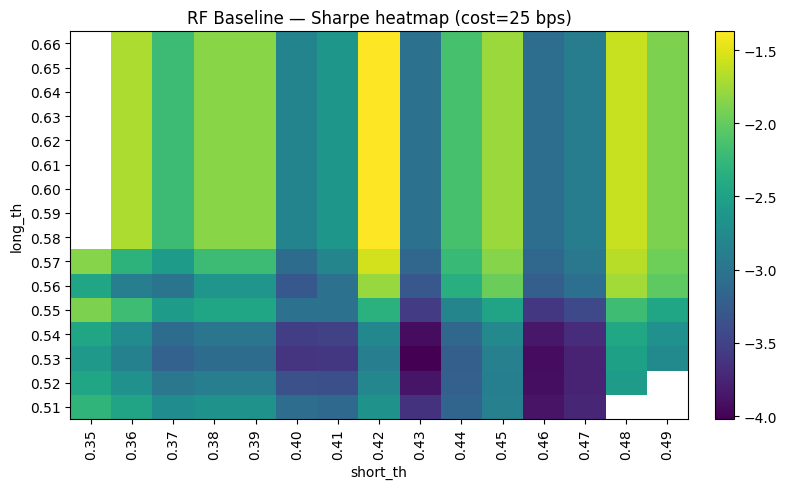

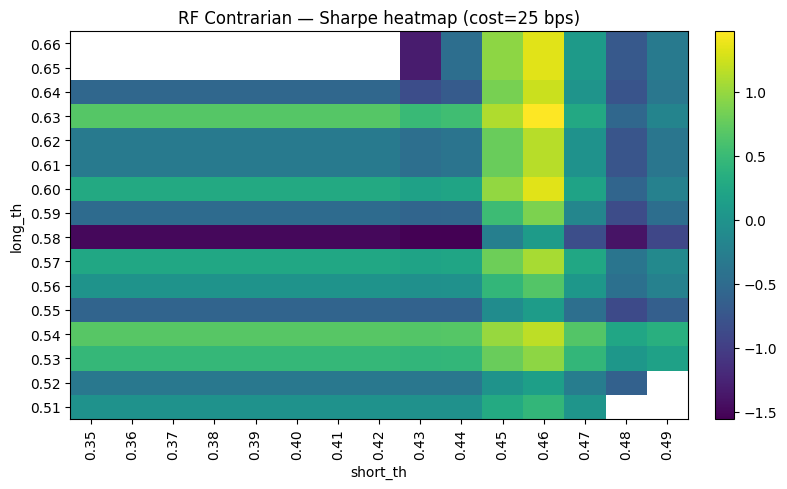

In [19]:
# --- Block 10b: Threshold grid for RF (baseline & contrarian) ---

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

assert 'p_test_rf' in globals() and 'asset_ret_next' in globals()

long_grid  = np.round(np.arange(0.50, 0.66, 0.01), 2)
short_grid = np.round(np.arange(0.35, 0.51, 0.01), 2)
cost_list  = [5.0, 10.0, 25.0]

rows = []
for c in cost_list:
    for lt in long_grid:
        for st in short_grid:
            if not (st < 0.5 < lt):
                continue
            if (lt - st) < 0.04:
                continue
            # Baseline RF
            s_b, _ = backtest_from_probs(p_test_rf, asset_ret_next,
                                         long_th=lt, short_th=st, cost_bps=c)
            # Contrarian RF
            s_c, _ = backtest_from_probs(1.0 - p_test_rf, asset_ret_next,
                                         long_th=lt, short_th=st, cost_bps=c)
            rows.append({"mode":"baseline","cost_bps":c,"long_th":lt,"short_th":st,
                         "Sharpe":s_b["Sharpe"],"CAGR":s_b["CAGR"]})
            rows.append({"mode":"contrarian","cost_bps":c,"long_th":lt,"short_th":st,
                         "Sharpe":s_c["Sharpe"],"CAGR":s_c["CAGR"]})

grid_rf = pd.DataFrame(rows)
print("RF runs:", len(grid_rf))

def heatmap(df, cost, mode, metric="Sharpe"):
    sub = df[(df["cost_bps"]==cost) & (df["mode"]==mode)].copy()
    piv = sub.pivot(index="long_th", columns="short_th", values=metric)
    piv = piv.reindex(index=sorted(piv.index), columns=sorted(piv.columns))
    plt.figure(figsize=(8,5))
    im = plt.imshow(piv.values, aspect="auto", origin="lower")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(f"RF {mode.capitalize()} — {metric} heatmap (cost={cost:.0f} bps)")
    plt.xlabel("short_th"); plt.ylabel("long_th")
    plt.xticks(range(len(piv.columns)), [f"{c:.2f}" for c in piv.columns], rotation=90)
    plt.yticks(range(len(piv.index)),   [f"{r:.2f}" for r in piv.index])
    plt.tight_layout(); plt.show()

for c in cost_list:
    heatmap(grid_rf, c, "baseline",  "Sharpe")
    heatmap(grid_rf, c, "contrarian","Sharpe")


Top 20 RF (Gini) importances:


,0
ret_1d,0.075253
Close_filled,0.071833
heards_price_std,0.065688
heards_price_min,0.063785
heards_price_max,0.059309
heards_price_median,0.057721
heards_price_mean,0.057130
net_raise_lower,0.055653
net_offer_bid,0.055112
volume_max_sum,0.045027


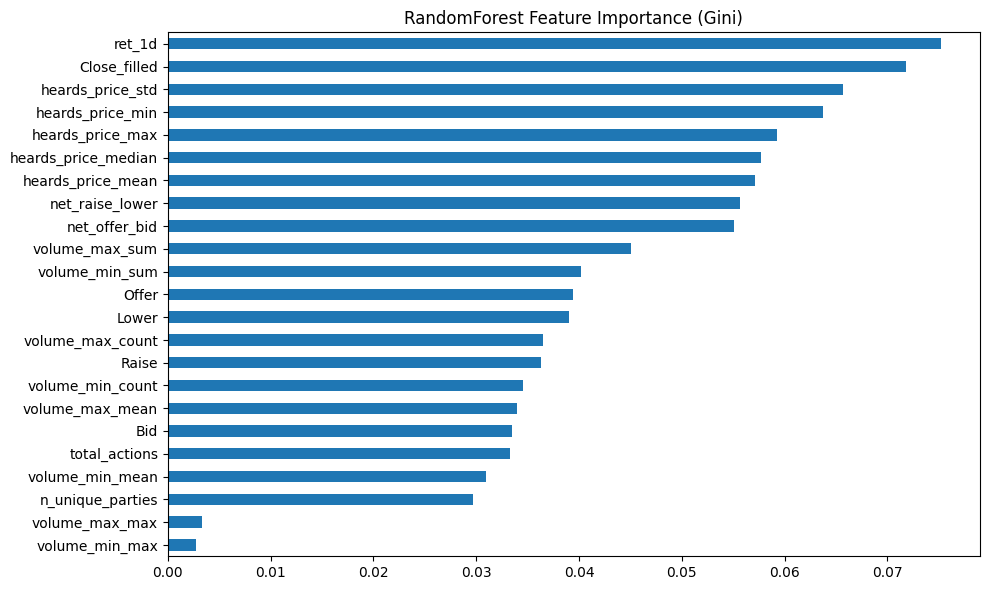

Top 15 by permutation ΔSharpe (more negative = more important):


,feature,delta_sharpe_mean,delta_sharpe_std,delta_cagr_mean,delta_cagr_std
0,n_unique_parties,-1.702857,0.314755,-0.468785,0.070254
1,volume_max_sum,-1.224141,0.427603,-0.361687,0.103098
2,Bid,-0.787931,0.725197,-0.272965,0.161403
3,volume_max_mean,-0.683478,0.272631,-0.216434,0.082532
4,ret_1d,-0.681526,0.380916,-0.224983,0.112666
5,volume_min_mean,-0.645262,0.167716,-0.211559,0.048234
6,heards_price_max,-0.602185,0.264394,-0.200704,0.086755
7,volume_max_count,-0.572745,0.329195,-0.184515,0.096229
8,heards_price_mean,-0.527108,0.181352,-0.177444,0.051715
9,Close_filled,-0.517893,0.337089,-0.160736,0.102254


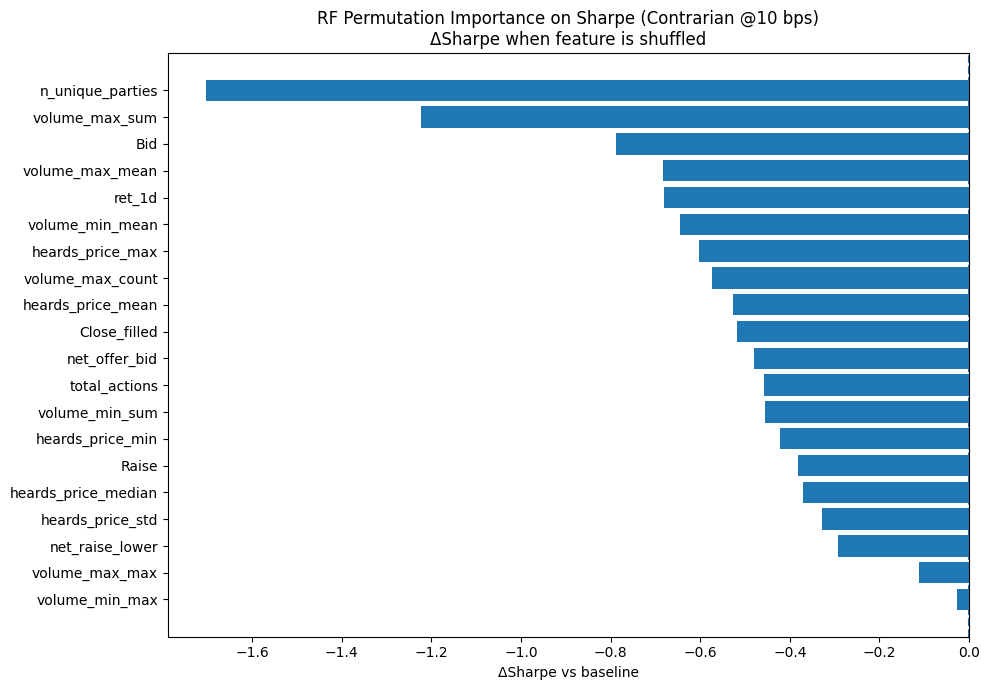

In [20]:
# --- Block 10c: RF feature importance (Gini) + permutation ΔSharpe for contrarian ---

# 1) Gini importances
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 20 RF (Gini) importances:")
display(imp.head(20))

plt.figure(figsize=(10,6))
imp.head(25).iloc[::-1].plot(kind="barh")
plt.title("RandomForest Feature Importance (Gini)")
plt.tight_layout(); plt.show()

# 2) Permutation ΔSharpe (contrarian)
rng = np.random.default_rng(42)
base_sum, _ = backtest_from_probs(1.0 - p_test_rf, asset_ret_next,
                                  long_th=best_long, short_th=best_short, cost_bps=best_cost)
base_sharpe = base_sum["Sharpe"]; base_cagr = base_sum["CAGR"]

perm_rows = []
n_repeats = 5
for feat in X_test.columns:
    dS, dC = [], []
    for _ in range(n_repeats):
        Xp = X_test.copy()
        Xp[feat] = rng.permutation(Xp[feat].values)
        p_perm = pd.Series(rf.predict_proba(Xp)[:,1], index=Xp.index)
        s_perm, _ = backtest_from_probs(1.0 - p_perm, asset_ret_next,
                                        long_th=best_long, short_th=best_short, cost_bps=best_cost)
        dS.append(s_perm["Sharpe"] - base_sharpe)
        dC.append(s_perm["CAGR"]  - base_cagr)
    perm_rows.append({
        "feature": feat,
        "delta_sharpe_mean": float(np.mean(dS)),
        "delta_sharpe_std":  float(np.std(dS)),
        "delta_cagr_mean":   float(np.mean(dC)),
        "delta_cagr_std":    float(np.std(dC)),
    })

perm_rf = pd.DataFrame(perm_rows).sort_values("delta_sharpe_mean").reset_index(drop=True)
print("Top 15 by permutation ΔSharpe (more negative = more important):")
display(perm_rf.head(15))

plt.figure(figsize=(10,7))
sub = perm_rf.head(20).iloc[::-1]
plt.barh(sub["feature"], sub["delta_sharpe_mean"])
plt.axvline(0, linestyle="--")
plt.title("RF Permutation Importance on Sharpe (Contrarian @10 bps)\nΔSharpe when feature is shuffled")
plt.xlabel("ΔSharpe vs baseline")
plt.tight_layout(); plt.show()



=== XGBoost — Contrarian @10 bps ===
days: 133
trades: 41
turnover_sum: 71.0000
total_return: -1.96%
CAGR: -3.68%
Sharpe: 0.02
MaxDD: -23.26%
HitRate: 44.36%
cost_bps: 10.0000
long_th: 0.5400
short_th: 0.4600
target_vol: None


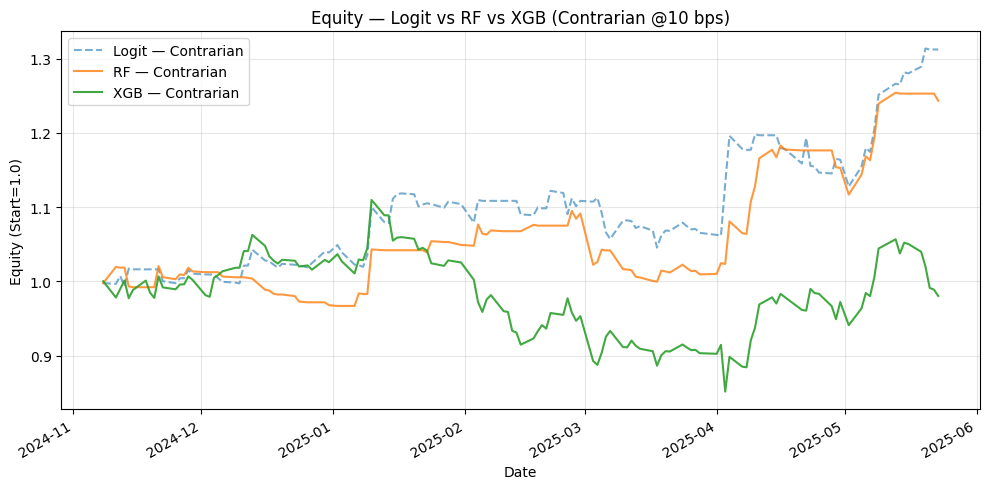

In [21]:
# --- Block 10d: XGBoost (optional) ---

!pip -q install xgboost

import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    scale_pos_weight=float((y_train==0).sum() / max(1,(y_train==1).sum()))
)

xgb_clf.fit(X_train, y_train)
p_test_xgb = pd.Series(xgb_clf.predict_proba(X_test)[:,1], index=X_test.index)

xgb_contra_sum, xgb_contra_daily = backtest_from_probs(1.0 - p_test_xgb, asset_ret_next,
                                                       long_th=best_long, short_th=best_short, cost_bps=best_cost)

show_perf("XGBoost — Contrarian @10 bps", xgb_contra_sum)

plt.figure(figsize=(10,5))
logit_daily["equity"].plot(label="Logit — Contrarian", linestyle="--", alpha=0.6)
rf_contra_daily["equity"].plot(label="RF — Contrarian", alpha=0.8)
xgb_contra_daily["equity"].plot(label="XGB — Contrarian", alpha=0.9)
plt.title("Equity — Logit vs RF vs XGB (Contrarian @10 bps)")
plt.xlabel("Date"); plt.ylabel("Equity (Start=1.0)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In [22]:
# Requires: logit_clf, rf, (optional) xgb_clf; X (or X_train) to grab feature names
import joblib, json, os, zipfile, sklearn, numpy as np
from datetime import datetime

os.makedirs("models_bundle", exist_ok=True)

# 1) Save models
joblib.dump(logit_clf, "models_bundle/logit_contrarian.pkl")
if 'rf' in globals(): joblib.dump(rf, "models_bundle/rf.pkl")
if 'xgb_clf' in globals(): joblib.dump(xgb_clf, "models_bundle/xgb.pkl")

# 2) Save feature spec + run params (EDIT thresholds/costs if you prefer different defaults)
feature_names = list(X.columns)  # full feature set used by Model 1
meta = {
    "created_at_utc": datetime.utcnow().isoformat()+"Z",
    "sklearn_version": sklearn.__version__,
    "numpy_version": np.__version__,
    "label_shift_days": 1,
    "execution_defaults": {
        "contrarian": True,
        "long_th": 0.54,
        "short_th": 0.46,
        "cost_bps": 10.0
    },
    "filters_used": {
        "price_basis": "MOPS 380",
        "location": "Straits"
    },
    "feature_names": feature_names
}
with open("models_bundle/feature_spec.json", "w") as f:
    json.dump(meta, f, indent=2)

# 3) Zip
with zipfile.ZipFile("models_bundle.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for fn in os.listdir("models_bundle"):
        z.write(os.path.join("models_bundle", fn), arcname=fn)

print("Saved:", os.listdir("models_bundle"))
print("Bundle: models_bundle.zip")


Saved: ['feature_spec.json', 'logit_contrarian.pkl', 'xgb.pkl', 'rf.pkl']
Bundle: models_bundle.zip


In [23]:
from google.colab import files
files.download("models_bundle.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>